# Prediction

An investor wants to make sure that their investment is going to be profitable in the future. If it will grow and do well 5 to 20 years from now. Is there a way that they can rest reassured in company that it will be successful based on what they know now? How sure of it can we be? what does the return look like? where can I find them? 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn import cluster
import sklearn
import seaborn as sns
from sklearn import decomposition
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn import svm
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from scipy.stats import boxcox
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# allow us to see all columns
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_excel("../Datasets_P1/Cost_Provider.xlsx")
df

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62
0,1089712,495134,RIDGECREST MANOR NURSING & REHAB CTR,DUFFIELD,VA,24244,SCOTT,2014-11-01,2014-12-31,4,549090,2015,1366877.0,292277.0,NaN,54091.0,311430.0,1800296.0,154022.0,1800296.0,1209322.0,279666.0,59343.0,311430.0,1520630.0,120.0,NaN,5667.0,2.0,40.0,6.0,48.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,117929.0,765020.0,7320.0,211585.0,534.0,5853.0,333.0,6720.0,9.0,35.0,5.0,49.0,311431.0,333.0,453591.0,55061.0,311430.0,453590.0,-729268.0,NaN,NaN,120.0,-1.0,NaN,311308.0,80664.0,660232.0,137.14,NaN,NaN,NaN,66.60,1182049.0,765020.0,167.23,1439227.0,123.0,NaN,NaN,U,157 ROSS-CARTER BLVD,28700.0,NaN,495134.0,RIDGECREST MANOR NURSING & REHABILITATION,DUFFIELD,VA,24244.0,Scott,For profit - Corporation,120.0,102.0,Medicare and Medicaid,NO,"RIDGECREST MANOR NURSING AND REHABILITATION, LLC",30279,N,N,N,Both,Yes,1,NaN,1.0,NaN,2.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,2.58824,0.95833,0.73382,1.69216,4.28039,0.05588,2.38063,0.79002,1.36045,4.53110,2.66769,1.00683,0.40303,3.80787,13,13,0,72,42110,1,0,72,0,10,0,0,0.0,0.0,42339.0,NaN,NaN,NaN
1,1091410,75417,REGENCY HEIGHTS OF NORWICH LLC,NORWICH,CT,6360,NEW LONDON,2014-10-01,2014-12-14,4,1886441,2015,1326379.0,NaN,NaN,-339775.0,-4896947.0,2843541.0,393088.0,2843541.0,3005301.0,426716.0,407352.0,-588469.0,2416825.0,114.0,36000.0,2596536.0,38.0,NaN,23.0,61.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,12590.0,1687456.0,8550.0,207903.0,7241.0,NaN,856.0,8097.0,36.0,NaN,23.0,59.0,-588469.0,856.0,2765768.0,671306.0,-4896947.0,6584403.0,36000.0,NaN,NaN,114.0,3818635.0,NaN,-588476.0,559430.0,1118860

In [5]:
# Sort values to ensure proper year alignment
df = df.sort_values(by=["Provider_CCN", "Year"])

# Step 1: Calculate Change in Total Equity (General Fund Balance)
df["Equity_Change"] = df.groupby("Provider_CCN")["General_fund_balance"].diff()

# Step 2: Calculate Owner Contributions
df["Owner_Contributions"] = df.groupby("Provider_CCN").apply(
    lambda x: x["General_fund_balance"].shift(-1) - x["General_fund_balance"] - x["Net_Income"]
).reset_index(level=0, drop=True)

# Step 3: Calculate Withdrawals (D)
df["Withdrawals"] = df["Net_Income"] - df["Equity_Change"] - df["Owner_Contributions"]


C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\3141047218.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["Owner_Contributions"] = df.groupby("Provider_CCN").apply(


In [6]:
# Define the EBITDA multiple
ebitda_multiple = 7.0

# Calculate the Business Valuation
df['Business_Valuation'] = df['Total_Income'] * ebitda_multiple


In [7]:
import pandas as pd

# Filter data for the years 2016 to 2020
df_filtered = df[(df['Year'] >= 2016) & (df['Year'] <= 2020)]

# Ensure no duplicates, aggregate if necessary (e.g., summing for Withdrawals and Total Income)
df_filtered = df_filtered.groupby(['Year', 'Provider_CCN'], as_index=False).agg({
    'Withdrawals': 'sum',  # Summing Withdrawals
    'Business_Valuation': 'last',  # Taking the last Business Valuation per year
    'Total_Income': 'sum'  # Assuming Total Income can be summed for ROI calculation
})

# Calculate starting and ending valuations, and total dividends
starting_valuation = df_filtered[df_filtered['Year'] == 2016].groupby('Provider_CCN')['Business_Valuation'].first()
ending_valuation = df_filtered[df_filtered['Year'] == 2020].groupby('Provider_CCN')['Business_Valuation'].last()
total_dividends = df_filtered.groupby('Provider_CCN')['Withdrawals'].sum()

# Merge the calculated values into a DataFrame
roi_df = pd.DataFrame({
    'Starting_Valuation': starting_valuation,
    'Ending_Valuation': ending_valuation,
    'Total_Dividends': total_dividends
})

# Calculate ROI
roi_df['ROI'] = (roi_df['Ending_Valuation'] + roi_df['Total_Dividends'] - roi_df['Starting_Valuation']) / roi_df['Starting_Valuation']

# Display the results
print(roi_df)


              Starting_Valuation  Ending_Valuation  Total_Dividends        ROI
Provider_CCN                                                                  
15009                   386141.0         1346968.0         -40298.0   2.383919
15010                        NaN         6717816.0        -310331.0        NaN
15014                  1916173.0        -2290757.0         -31846.0  -2.212105
15015                  -286853.0         2453773.0         331850.0 -10.710977
15016                  6117517.0         3062297.0        6173204.0   0.509681
...                          ...               ...              ...        ...
676487                       NaN       -22700328.0              0.0        NaN
676488                       NaN           79436.0              0.0        NaN
676491                       NaN        -9875803.0              0.0        NaN
686123                       NaN       -13300406.0       -7973959.0        NaN
686124                       NaN        -3138814.0  

ROI Summary Statistics:
 count    1.349400e+04
mean    -9.446929e+00
std      3.831224e+04
min     -1.277156e+06
25%     -1.608688e+00
50%      4.416496e-02
75%      2.138665e+00
max      3.510503e+06
Name: ROI, dtype: float64

Correlation Matrix:
                          ROI  Starting_Valuation  Ending_Valuation  \
ROI                 1.000000            0.000005          0.006370   
Starting_Valuation  0.000005            1.000000          0.282630   
Ending_Valuation    0.006370            0.282630          1.000000   
Total_Dividends     0.002466            0.096513          0.126257   

                    Total_Dividends  
ROI                        0.002466  
Starting_Valuation         0.096513  
Ending_Valuation           0.126257  
Total_Dividends            1.000000  


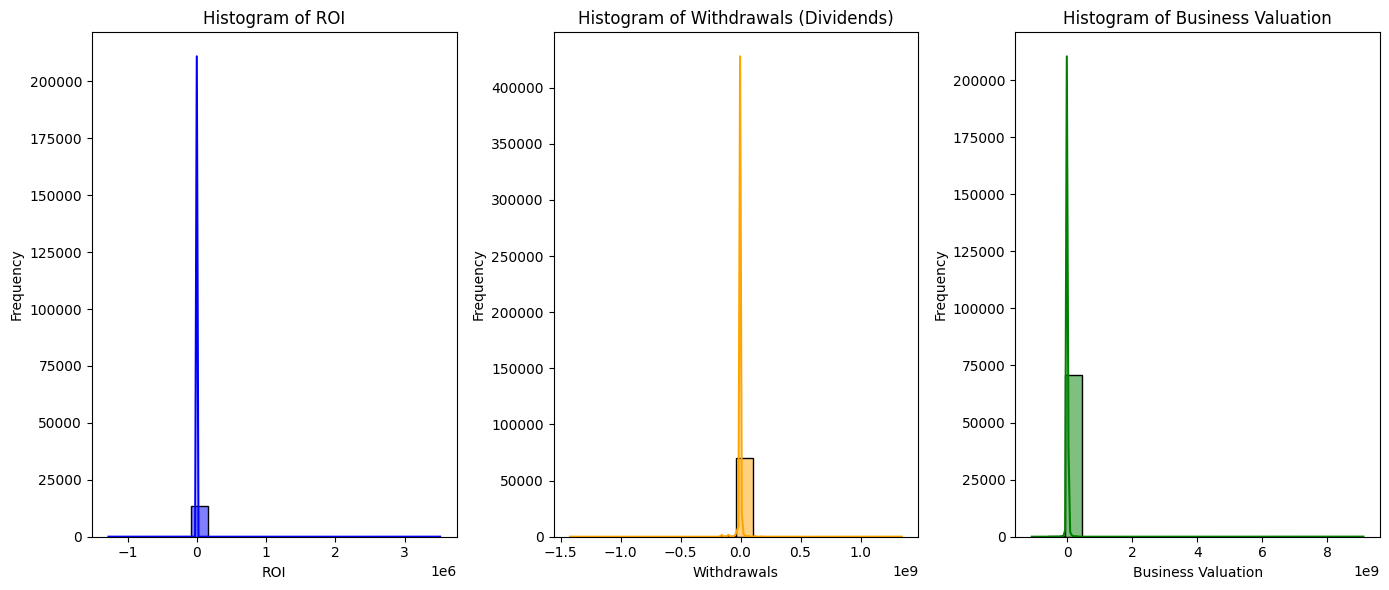

C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


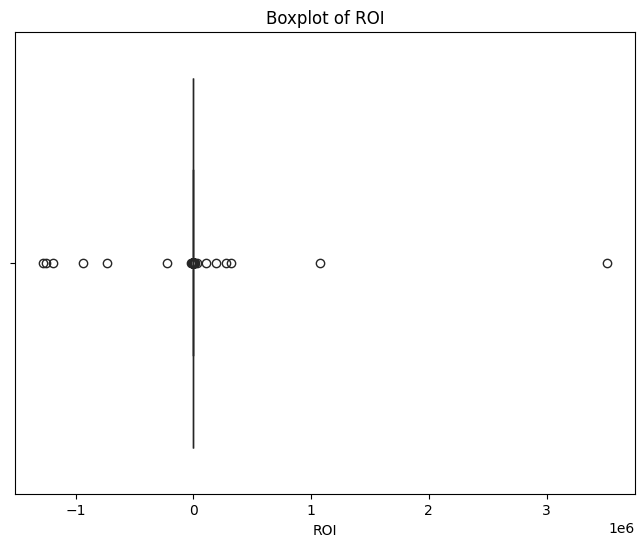


Top 5% Outliers in ROI:
               Starting_Valuation  Ending_Valuation  Total_Dividends  \
Provider_CCN                                                          
15045                 -2530682.0       -12670756.0     -158035720.0   
15212                  -319088.0        -5348791.0       -4573399.0   
15221                   457065.0        11190725.0        1989050.0   
15303                  -489188.0        -4271638.0       -7879330.0   
15361                    89159.0         6726489.0        -128606.0   
...                          ...               ...              ...   
676253                  809662.0        12062036.0        8025233.0   
676255                  486969.0         2349606.0       21727108.0   
676262                  161840.0        11291434.0        6939525.0   
676274                  243831.0         6333460.0         806662.0   
676350                  371413.0         9467087.0        1296794.0   

                     ROI  
Provider_CCN           

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check summary statistics for ROI, including mean, median, and std
roi_summary = roi_df['ROI'].describe()

# Display summary statistics
print("ROI Summary Statistics:\n", roi_summary)

# Check correlations between ROI, Starting_Valuation, Ending_Valuation, and Total_Dividends
correlations = roi_df[['ROI', 'Starting_Valuation', 'Ending_Valuation', 'Total_Dividends']].corr()
print("\nCorrelation Matrix:\n", correlations)

# Plot histograms for ROI, Withdrawals, and Business Valuations
plt.figure(figsize=(14, 6))

# Histogram for ROI
plt.subplot(1, 3, 1)
sns.histplot(roi_df['ROI'], kde=True, bins=20, color='blue')
plt.title('Histogram of ROI')
plt.xlabel('ROI')
plt.ylabel('Frequency')

# Histogram for Withdrawals (Dividends)
plt.subplot(1, 3, 2)
sns.histplot(df_filtered['Withdrawals'], kde=True, bins=20, color='orange')
plt.title('Histogram of Withdrawals (Dividends)')
plt.xlabel('Withdrawals')
plt.ylabel('Frequency')

# Histogram for Business Valuations
plt.subplot(1, 3, 3)
sns.histplot(df_filtered['Business_Valuation'], kde=True, bins=20, color='green')
plt.title('Histogram of Business Valuation')
plt.xlabel('Business Valuation')
plt.ylabel('Frequency')

# Display histograms
plt.tight_layout()
plt.show()

# Boxplot for ROI to check for outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=roi_df['ROI'], color='purple')
plt.title('Boxplot of ROI')
plt.xlabel('ROI')
plt.show()

# Check for outliers and any extreme values
outliers = roi_df[roi_df['ROI'] > roi_df['ROI'].quantile(0.95)]  # Top 5% outliers
print("\nTop 5% Outliers in ROI:\n", outliers)

# Mean and Median ROI
mean_roi = roi_df['ROI'].mean()
median_roi = roi_df['ROI'].median()

print(f"\nMean ROI: {mean_roi:.4f}")
print(f"Median ROI: {median_roi:.4f}")


In [9]:
# Step 1: Calculate the ROI for each provider
# First, calculate the Starting and Ending Valuation for each provider
df['Starting_Valuation'] = df.groupby('Provider_CCN')['Business_Valuation'].shift(0)  # Current year's Business Valuation
df['Ending_Valuation'] = df.groupby('Provider_CCN')['Business_Valuation'].shift(-1)  # Next year's Business Valuation
df['Total_Dividends'] = df.groupby('Provider_CCN')['Withdrawals'].shift(-1)  # Withdrawals from next year

# Step 2: Calculate ROI
df['ROI'] = (df['Ending_Valuation'] + df['Total_Dividends'] - df['Starting_Valuation']) / df['Starting_Valuation']

# Step 3: Align the ROI to the 2016 year for each Provider_CCN
# Filter out the 2016 year and create a dataframe with ROI only for 2016
roi_2016 = df[df['Year'] == 2016][['Provider_CCN', 'ROI']]

# Merge this ROI data with the main dataframe
df = df.merge(roi_2016, on='Provider_CCN', suffixes=('', '_2016'))  # Merge to align ROI with the 2016 row

# Step 4: Keep only the rows for years 2016 to 2020
df_filtered = df[df['Year'].between(2016, 2020)]

# Step 5: Clean up - Drop unnecessary columns and rename
df_filtered = df_filtered.drop(columns=['ROI'])  # Drop the temporary ROI column
df_filtered = df_filtered.rename(columns={'ROI_2016': 'ROI'})  # Rename to align ROI as the main column

# Now, df_filtered contains the ROI for 2016 in the respective rows with all the necessary columns intact.
# You can proceed with preparing this dataset for machine learning.


In [10]:
df_filtered

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI
1,1182953,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2016-07-01,2017-06-30,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,R,701 MONROE STREET,99901.0,733898.0,15009.0,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,35653.0,Franklin,For profit - Corporation,57.0,45.0,Medicare and Medicaid,NO,"BURNS NURSING HOME, INC.",25447,N,N,N,Both,Yes,5,NaN,5.0,NaN,3.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,2,2,0,8,42607,1,0,8,0,0,0,0,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255
2,1218411,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2017-07-01,2018-06-30,4,2252664,2017,729726.0,194435.0,713237.0,113412.0,1404621.0,3873936.0,1120364.0,3873936.0,4787423.0,NaN,NaN,58862.0,3873936.0,57.0,42681.0,NaN,45.0,26.0,94.0,165.0,4291.0,12437.0,2338.0,19066.0,45.0,26.0,94.0,165.0,NaN,1599056.0,20805.0,NaN,4291.0,12437.0,2338.0,19066.0,45.0,26.0,94.0,

In [11]:
# Step 1: Find the Provider_CCN that appear in every year from 2016 to 2020
years_required = set(range(2016, 2021))  # Set of years 2016 to 2020

# Step 2: Group by 'Provider_CCN' and count unique years for each
provider_year_count = df_filtered.groupby('Provider_CCN')['Year'].nunique()

# Step 3: Filter Provider_CCNs that have 5 unique years (2016, 2017, 2018, 2019, 2020)
providers_in_all_years = provider_year_count[provider_year_count == 5].index

# Step 4: Filter the dataframe to keep only these providers
df_filtered_all_years = df_filtered[df_filtered['Provider_CCN'].isin(providers_in_all_years)]

# Now, df_filtered_all_years contains only the Provider_CCN that are present in every year (2016-2020).


In [12]:
df_filtered_all_years

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI
1,1182953,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2016-07-01,2017-06-30,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,R,701 MONROE STREET,99901.0,733898.0,15009.0,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,35653.0,Franklin,For profit - Corporation,57.0,45.0,Medicare and Medicaid,NO,"BURNS NURSING HOME, INC.",25447,N,N,N,Both,Yes,5,NaN,5.0,NaN,3.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,2,2,0,8,42607,1,0,8,0,0,0,0,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255
2,1218411,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2017-07-01,2018-06-30,4,2252664,2017,729726.0,194435.0,713237.0,113412.0,1404621.0,3873936.0,1120364.0,3873936.0,4787423.0,NaN,NaN,58862.0,3873936.0,57.0,42681.0,NaN,45.0,26.0,94.0,165.0,4291.0,12437.0,2338.0,19066.0,45.0,26.0,94.0,165.0,NaN,1599056.0,20805.0,NaN,4291.0,12437.0,2338.0,19066.0,45.0,26.0,94.0,

In [13]:
# Step 1: Filter df_filtered_all_years for Year 2016
df_2016 = df_filtered_all_years[df_filtered_all_years['Year'] == 2016]


In [14]:
df_2016

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI
1,1182953,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2016-07-01,2017-06-30,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,R,701 MONROE STREET,99901.0,733898.0,15009.0,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,35653.0,Franklin,For profit - Corporation,57.0,45.0,Medicare and Medicaid,NO,"BURNS NURSING HOME, INC.",25447,N,N,N,Both,Yes,5,NaN,5.0,NaN,3.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,2,2,0,8,42607,1,0,8,0,0,0,0,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255
8,1182059,15014,EASTVIEW REHAB & HEALTHCARE CTR,BIRMINGHAM,AL,35206,JEFFERSON,2016-07-01,2017-06-30,4,4506311,2016,1274154.0,361606.0,345763.0,106682.0,-426152.0,7149478.0,1170082.0,7149478.0,7448712.0,-526230.0,299288.0,-154259.0,7675708.0,90.0,2775.0,159178.0,42.0,49.0,48.0,139.0,3470.0,24218.0,2772.0,30460.0,37.0,72.0,23.0,132.0,129851.0,780770.0,32850.0,1137276.0,3470

THIS IS THE ENTIRE DATASET WITH A TARGET VARIABLE THAT WE CAN MAKE 0,1 if we want. 

In [15]:
import numpy as np

# Method 1: Using IQR to identify and remove outliers
Q1 = df_2016['ROI'].quantile(0.02)
Q3 = df_2016['ROI'].quantile(0.98)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers_iqr = df_2016[(df_2016['ROI'] >= lower_bound) & (df_2016['ROI'] <= upper_bound)]

# Method 2: Using Z-score to identify and remove outliers
from scipy.stats import zscore

# Calculate Z-scores for the ROI column
z_scores = zscore(df_2016['ROI'])

# Define a threshold (commonly 3 standard deviations away from the mean)
threshold = 3

# Filter out outliers based on Z-score
df_no_outliers_zscore = df_2016[np.abs(z_scores) < threshold]

# You can choose either df_no_outliers_iqr or df_no_outliers_zscore


In [16]:
# Before removing outliers, check the initial number of rows
initial_rows = df_2016.shape[0]

# Method 1: Using IQR to filter out outliers
outliers_iqr = df_2016[~df_2016.index.isin(df_no_outliers_iqr.index)]
outliers_iqr_count = outliers_iqr.shape[0]

# Method 2: Using Z-score to filter out outliers
outliers_zscore = df_2016[~df_2016.index.isin(df_no_outliers_zscore.index)]
outliers_zscore_count = outliers_zscore.shape[0]

# After filtering, check the number of rows remaining
final_rows_iqr = df_no_outliers_iqr.shape[0]
final_rows_zscore = df_no_outliers_zscore.shape[0]

# Display the number of outliers removed
print(f"Initial rows: {initial_rows}")
print(f"Outliers removed using IQR: {outliers_iqr_count}")
print(f"Remaining rows after IQR filtering: {final_rows_iqr}")
print(f"Outliers removed using Z-score: {outliers_zscore_count}")
print(f"Remaining rows after Z-score filtering: {final_rows_zscore}")


Initial rows: 15227
Outliers removed using IQR: 295
Remaining rows after IQR filtering: 14932
Outliers removed using Z-score: 15227
Remaining rows after Z-score filtering: 0


In [17]:
df_no_outliers_iqr

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI
1,1182953,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2016-07-01,2017-06-30,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,R,701 MONROE STREET,99901.0,733898.0,15009.0,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,35653.0,Franklin,For profit - Corporation,57.0,45.0,Medicare and Medicaid,NO,"BURNS NURSING HOME, INC.",25447,N,N,N,Both,Yes,5,NaN,5.0,NaN,3.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,2,2,0,8,42607,1,0,8,0,0,0,0,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255
8,1182059,15014,EASTVIEW REHAB & HEALTHCARE CTR,BIRMINGHAM,AL,35206,JEFFERSON,2016-07-01,2017-06-30,4,4506311,2016,1274154.0,361606.0,345763.0,106682.0,-426152.0,7149478.0,1170082.0,7149478.0,7448712.0,-526230.0,299288.0,-154259.0,7675708.0,90.0,2775.0,159178.0,42.0,49.0,48.0,139.0,3470.0,24218.0,2772.0,30460.0,37.0,72.0,23.0,132.0,129851.0,780770.0,32850.0,1137276.0,3470

ROI Summary Statistics:
 count    14932.000000
mean        -0.080733
std          8.646665
min        -87.255977
25%         -1.040253
50%         -0.157648
75%          0.726611
max         88.794315
Name: ROI, dtype: float64

Correlation Matrix:
                          ROI  Starting_Valuation  Ending_Valuation  \
ROI                 1.000000            0.000005          0.006370   
Starting_Valuation  0.000005            1.000000          0.282630   
Ending_Valuation    0.006370            0.282630          1.000000   
Total_Dividends     0.002466            0.096513          0.126257   

                    Total_Dividends  
ROI                        0.002466  
Starting_Valuation         0.096513  
Ending_Valuation           0.126257  
Total_Dividends            1.000000  


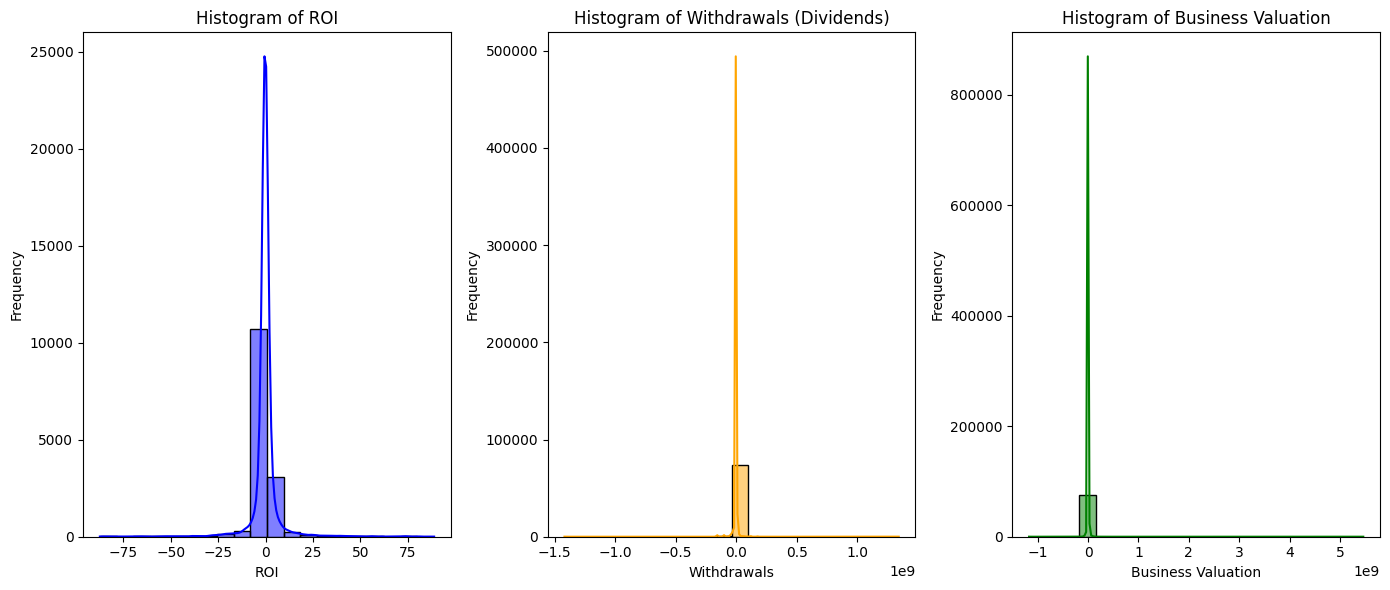

C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


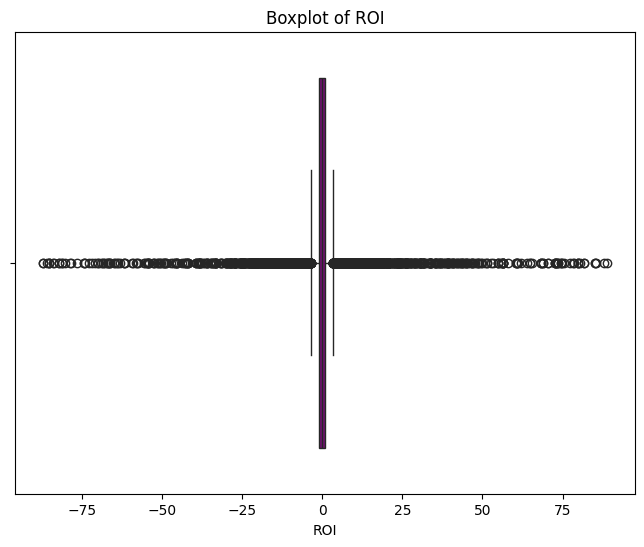


Top 5% Outliers in ROI:
         rpt_rec_num  Provider_CCN                       Facility_Name  \
104         1156126         15037        WOODLEY MANOR HEALTH & REHAB   
137         1238702         15045          EAMC - LANIER NURSING HOME   
221         1174356         15066       TERRACE MANOR NURSING & REHAB   
706         1182427         15177        WOODHAVEN MANOR NURSING HOME   
1646        1162528         35068         PUEBLO SPRINGS REHAB CENTER   
...             ...           ...                                 ...   
105272      1216993        676314  LA HACIENDA NURSING & REHAB CENTER   
105306      1173916        676318     WINDMILL NURSING & REHAB CENTER   
105344      1173917        676325       TRISUN CARE CENTER - LAKESIDE   
105490      1174482        676346             SENIOR CARE OF EDINBURG   
105809      1212928        676390             LEXINGTON MEDICAL LODGE   

                City State_Code Zip_Code      County Fiscal_Year_Begin_Date  \
104       MONTGOME

In [18]:
# Check summary statistics for ROI, including mean, median, and std
roi_summary = df_no_outliers_iqr['ROI'].describe()

# Display summary statistics
print("ROI Summary Statistics:\n", roi_summary)

# Check correlations between ROI, Starting_Valuation, Ending_Valuation, and Total_Dividends
correlations = roi_df[['ROI', 'Starting_Valuation', 'Ending_Valuation', 'Total_Dividends']].corr()
print("\nCorrelation Matrix:\n", correlations)

# Plot histograms for ROI, Withdrawals, and Business Valuations
plt.figure(figsize=(14, 6))

# Histogram for ROI
plt.subplot(1, 3, 1)
sns.histplot(df_no_outliers_iqr['ROI'], kde=True, bins=20, color='blue')
plt.title('Histogram of ROI')
plt.xlabel('ROI')
plt.ylabel('Frequency')

# Histogram for Withdrawals (Dividends)
plt.subplot(1, 3, 2)
sns.histplot(df_filtered['Withdrawals'], kde=True, bins=20, color='orange')
plt.title('Histogram of Withdrawals (Dividends)')
plt.xlabel('Withdrawals')
plt.ylabel('Frequency')

# Histogram for Business Valuations
plt.subplot(1, 3, 3)
sns.histplot(df_filtered['Business_Valuation'], kde=True, bins=20, color='green')
plt.title('Histogram of Business Valuation')
plt.xlabel('Business Valuation')
plt.ylabel('Frequency')

# Display histograms
plt.tight_layout()
plt.show()

# Boxplot for ROI to check for outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_no_outliers_iqr['ROI'], color='purple')
plt.title('Boxplot of ROI')
plt.xlabel('ROI')
plt.show()

# Check for outliers and any extreme values
outliers = df_no_outliers_iqr[df_no_outliers_iqr['ROI'] > df_no_outliers_iqr['ROI'].quantile(0.95)]  # Top 5% outliers
print("\nTop 5% Outliers in ROI:\n", outliers)

# Mean and Median ROI
mean_roi = df_no_outliers_iqr['ROI'].mean()
median_roi = df_no_outliers_iqr['ROI'].median()

print(f"\nMean ROI: {mean_roi:.4f}")
print(f"Median ROI: {median_roi:.4f}")

In [19]:
# Filter the 'City' column to only keep integer values
unique_cities_int = df_no_outliers_iqr['City'].apply(lambda x: isinstance(x, int)).unique()

# Get the unique integer cities
unique_cities_int_values = df_no_outliers_iqr[df_no_outliers_iqr['City'].apply(lambda x: isinstance(x, int))]['City'].unique()

# Display the unique integer cities
print(unique_cities_int_values)
# Replace integer values in the 'City' column with "Unknown"
df_no_outliers_iqr['City'] = df_no_outliers_iqr['City'].apply(lambda x: "Unknown" if isinstance(x, int) else x)


[9]


C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\3263239025.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['City'] = df_no_outliers_iqr['City'].apply(lambda x: "Unknown" if isinstance(x, int) else x)


In [20]:
# Filter the 'City' column to only keep integer values
unique_cities_int = df_no_outliers_iqr['County'].apply(lambda x: isinstance(x, int)).unique()

# Get the unique integer cities
unique_cities_int_values = df_no_outliers_iqr[df_no_outliers_iqr['County'].apply(lambda x: isinstance(x, int))]['County'].unique()

# Display the unique integer cities
print(unique_cities_int_values)
# Replace integer values in the 'City' column with "Unknown"
df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, int) else x)


[13020 46540 31084]


C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\373426462.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, int) else x)


In [21]:
# Replace values containing '<' in the 'County' column with "Unknown"
df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, str) and '<' in x else x)
# Replace integer values in the 'City' column with "Unknown"
df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, float) else x)


C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\3534501455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, str) and '<' in x else x)
C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\3534501455.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['County'] = df_no_outliers_iqr['County'].apply(lambda x: "Unknown" if isinstance(x, float) else x)


In [22]:
from sklearn.preprocessing import LabelEncoder

df_no_outliers_iqr['Facility_Name_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['Facility_Name'])
df_no_outliers_iqr['City_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['City'])
df_no_outliers_iqr['State_Code_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['State_Code'])
df_no_outliers_iqr['County_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['County'])

C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\684934040.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['Facility_Name_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['Facility_Name'])
C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\684934040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers_iqr['City_enc'] = LabelEncoder().fit_transform(df_no_outliers_iqr['City'])
C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\684934040.py:5: SettingWithCopyWarning: 

In [23]:
df_no_outliers_iqr

,rpt_rec_num,Provider_CCN,Facility_Name,City,State_Code,Zip_Code,County,Fiscal_Year_Begin_Date,Fiscal_Year_End_Date,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Rural_versus_Urban,Street_Address,Medicare_CBSA_Number,Land,provnum,PROVNAME,CITY,STATE,ZIP,COUNTY_NAME,OWNERSHIP,BEDCERT,RESTOT,CERTIFICATION,INHOSP,LBN,PARTICIPATION_DATE,CCRC_FACIL,SFF,CHOW_LAST_12MOS,resfamcouncil,sprinkler_status,overall_rating,overall_rating_fn,survey_rating,survey_rating_fn,quality_rating,quality_rating_fn,staffing_rating,staffing_rating_fn,RN_staffing_rating,rn_staffing_rating_fn,STAFFING_FLAG,PT_STAFFING_FLAG,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,cycle_1_defs,cycle_1_nfromdefs,cycle_1_nfromcomp,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_REVISIT_SCORE,CYCLE_1_TOTAL_SCORE,incident_cnt,cmplnt_cnt,FINE_CNT,FINE_TOT,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI,Facility_Name_enc,City_enc,State_Code_enc,County_enc
1,1182953,15009,BURNS NURSING HOME,RUSSELVILLE,AL,35653,FRANKLIN,2016-07-01,2017-06-30,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,R,701 MONROE STREET,99901.0,733898.0,15009.0,"BURNS NURSING HOME, INC.",RUSSELLVILLE,AL,35653.0,Franklin,For profit - Corporation,57.0,45.0,Medicare and Medicaid,NO,"BURNS NURSING HOME, INC.",25447,N,N,N,Both,Yes,5,NaN,5.0,NaN,3.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,2,2,0,8,42607,1,0,8,0,0,0,0,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255,1770,3752,1,577
8,1182059,15014,EASTVIEW REHAB & HEALTHCARE CTR,BIRMINGHAM,AL,35206,JEFFERSON,2016-07-01,2017-06-30,4,4506311,2016,1274154.0,361606.0,345763.0,106682.0,-426152.0,7149478.0,1170082.0,7149478.0,7448712.0,-526230.0,299288.0,-154259.0,7675708.0,90.0,2775.0,159178.0,42.0,49.0,48.0,139.0,3470.0,24218.0,2772.0,

In [24]:
beforecorr = df_no_outliers_iqr


In [25]:
# Convert specified columns to int64
columns_to_convert = ["Provider_CCN","Type_of_Control", "County_enc", "State_Code_enc", "City_enc", "Facility_Name_enc"]

# Ensure columns exist in the dataset before converting
for col in columns_to_convert:
    if col in beforecorr.columns:
        beforecorr[col] = beforecorr[col].astype("int64")

# Verify the conversion
print(beforecorr[columns_to_convert].dtypes)


Provider_CCN         int64
Type_of_Control      int64
County_enc           int64
State_Code_enc       int64
City_enc             int64
Facility_Name_enc    int64
dtype: object


C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\2185012922.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beforecorr[col] = beforecorr[col].astype("int64")
C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\2185012922.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beforecorr[col] = beforecorr[col].astype("int64")
C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\2185012922.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [26]:
# Select only columns with int64 and float types
numeric_beforecorr = beforecorr.select_dtypes(include=['int64', 'float64'])

# Display the first few rows of the filtered dataset
numeric_beforecorr.head()


,rpt_rec_num,Provider_CCN,Type_of_Control,Overhead_Non_Salary_Costs,Year,Accounts_Receivable,Accounts_payable,Buildings,Cash_on_hand_and_in_banks,General_fund_balance,Gross_Revenue,Inpatient_PPS_Amount,Inpatient_Revenue,Less_Total_Operating_Expense,Less_discounts_on_patients,Major_movable_equipment,Net_Income,Net_Patient_Revenue,Number_of_Beds,Other_Assets,Other_current_liabilities,SNF_Admissions_Other,SNF_Admissions_Title_XIX,SNF_Admissions_Title_XVIII,SNF_Admissions_Total,SNF_Days_Other,SNF_Days_Title_XIX,SNF_Days_Title_XVIII,SNF_Days_Total,SNF_Discharges_Title_Other,SNF_Discharges_Title_XIX,SNF_Discharges_Title_XVIII,SNF_Discharges_Total,Salaries_wages_and_fees_payable,Total_Assets,Total_Bed_Days_Available,Total_Costs,Total_Days_Other,Total_Days_Title_XIX,Total_Days_Title_XVIII,Total_Days_Total,Total_Discharges_Title_Other,Total_Discharges_Title_XIX,Total_Discharges_Title_XVIII,Total_Discharges_Total,Total_Income,Total_RUG_Days,Total_current_liabilities,Total_fixed_Assets,Total_fund_balances,Total_liabilities,Total_other_Assets,Fixed_equipment,Total_Charges,SNF_Number_of_Beds,Total_long_term_liabilities,Investments,Net_Income_from_service_to_patients,Wage-related_Costs_(core),Total_Salaries_(adjusted),SNF_Average_Length_of_Stay_Total,Notes_Payable,Other_long_term_liabilities,Allowable_Bad_Debts,SNF_Average_Length_of_Stay_Title_XVIII,Total_General_Inpatient_Care_Services_Revenue,Total_Liabilities_and_fund_balances,SNF_Average_Length_of_Stay_Title_XIX,Total_Current_Assets,Total_Other_Income,SNF_Bed_Days_Available,Prepaid_expenses,Medicare_CBSA_Number,Land,provnum,ZIP,BEDCERT,RESTOT,survey_rating,quality_rating,staffing_rating,RN_staffing_rating,AIDHRD,VOCHRD,RNHRD,TOTLICHRD,TOTHRD,PTHRD,exp_aide,exp_lpn,exp_rn,exp_total,adj_aide,adj_lpn,adj_rn,adj_total,PAYDEN_CNT,TOT_PENLTY_CNT,FILEDATE,Unnamed: 60,Unnamed: 61,Unnamed: 62,Equity_Change,Owner_Contributions,Withdrawals,Business_Valuation,Starting_Valuation,Ending_Valuation,Total_Dividends,ROI,Facility_Name_enc,City_enc,State_Code_enc,County_enc
1,1182953,15009,4,2136186,2016,685258.0,145567.0,747793.0,139888.0,1427672.0,4473068.0,1001406.0,4473068.0,4496263.0,NaN,NaN,55163.0,4473068.0,57.0,NaN,NaN,NaN,NaN,NaN,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,NaN,1573239.0,20805.0,NaN,2651.0,13497.0,2210.0,18358.0,85.0,490.0,91.0,666.0,55163.0,2210.0,145567.0,747793.0,1427672.0,145567.0,NaN,NaN,NaN,57.0,0.0,NaN,-23195.0,478282.0,2360077.0,27.56,NaN,NaN,NaN,24.29,4473068.0,1573239.0,27.54,825446.0,78358.0,NaN,NaN,99901.0,733898.0,15009.0,35653.0,57.0,45.0,5.0,3.0,5.0,5.0,2.74667,1.12667,1.08000,2.20667,4.95334,0.01222,2.64279,0.70611,1.08992,4.43882,2.55015,1.32434,0.74040,4.49813,0.0,0.0,42705.0,NaN,NaN,NaN,64592.0,-78214.0,68785.0,386141.0,386141.0,412034.0,5483.0,0.081255,1770,3752,1,577
8,1182059,15014,4,4506311,2016,1274154.0,361606.0,345763.0,106682.0,-426152.0,7149478.0,1170082.0,7149478.0,7448712.0,-526230.0,299288.0,-154259.0,7675708.0,90.0,2775.0,159178.0,42.0,49.0,48.0,139.0,3470.0,24218.0,2772.0,30460.0,37.0,72.0,23.0,132.0,129851.0,780770.0,32850.0,1137276.0,3470.0,24218.0,2772.0,30460.0,37.0,72.0,23.0,132.0,273739.0,2772.0,652904.0,814339.0,-426152.0,1206922.0,-1122483.0,767487.0,NaN,90.0,554018.0,NaN,226996.0,660960.0,2942401.0,230.76,NaN,NaN,NaN,120.52,5629259.0,780770.0,336.36,1088914.0,46743.0,NaN,NaN,13820.0,NaN,15014.0,35206.0,92.0,82.0,2.0,2.0,4.0,3.0,2.68476,1.57317,0.51646,2.08963,4.77439,0.00000,2.46446,0.61329,0.91941,3.99716,2.67304,2.12906,0.41972,4.81469,0.0,0.0,42705.0,NaN,NaN,NaN,-154259.0,77183.0,-77183.0,1916173.0,1916173.0,1926778.0,665163.0,0.352665,3352,367,1,802
15,1182687,15015,4,4228799,2016,978631.0,373345.0,NaN,109551.0,-352982.0,6879163.0,524461.0,6879163.0,7339324.0,-7606.0,420655.0,-242788.0,6886769.0,103.0,NaN,73629.0,NaN,NaN,NaN,NaN,12037.0,21516.0,1311.0,34864.0,NaN,NaN,NaN,NaN,139098.0,272673.0,37595.0,436934.0,12037.0,21516.0,1311.0,34864.0,NaN,NaN,NaN,NaN,-40979.0,1311.0,625646.0,225559.0,-352982.0,625655.0,-815703.0,180623.

In [27]:
# Ensure required categorical variables are included
required_columns = ["Provider_CCN", "State_Code_enc", "Type_of_Control", "Year"]

# Select only numeric columns
numeric_columns = beforecorr.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ensure required columns are included in the selection
selected_columns = list(set(numeric_columns + required_columns))  

# Create the filtered dataset
numeric_beforecorr = beforecorr[selected_columns]

# Compute correlation of all variables with ROI
correlation_matrix = numeric_beforecorr.corr()


In [28]:
# Select variables with correlation ≥ 0.015 (absolute value)
selected_columns = correlation_matrix.index[correlation_matrix["ROI"].abs() >= 0.015].tolist()

# Ensure the required columns are always included
for col in required_columns:
    if col not in selected_columns:
        selected_columns.append(col)

# Create a new dataset with only the selected columns
filtered_dataset = numeric_beforecorr[selected_columns]

# Display the selected variables
print("Selected Variables:", selected_columns)

# Show the first few rows of the filtered dataset
filtered_dataset.head()


Selected Variables: ['Total_Liabilities_and_fund_balances', 'Total_Days_Title_XVIII', 'SNF_Admissions_Title_XIX', 'exp_total', 'Total_long_term_liabilities', 'Cash_on_hand_and_in_banks', 'Accounts_Receivable', 'Total_Assets', 'Total_fund_balances', 'Total_other_Assets', 'Total_Current_Assets', 'General_fund_balance', 'Land', 'Fixed_equipment', 'Total_liabilities', 'Accounts_payable', 'Owner_Contributions', 'SNF_Days_Title_XVIII', 'exp_lpn', 'Total_Discharges_Title_XIX', 'Other_Assets', 'ROI', 'Total_Dividends', 'Withdrawals', 'Salaries_wages_and_fees_payable', 'SNF_Discharges_Title_XIX', 'Total_RUG_Days', 'Major_movable_equipment', 'Buildings', 'Total_current_liabilities', 'Facility_Name_enc', 'Total_fixed_Assets', 'Equity_Change', 'Provider_CCN', 'State_Code_enc', 'Type_of_Control', 'Year']


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Total_long_term_liabilities,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,General_fund_balance,Land,Fixed_equipment,Total_liabilities,Accounts_payable,Owner_Contributions,SNF_Days_Title_XVIII,exp_lpn,Total_Discharges_Title_XIX,Other_Assets,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,SNF_Discharges_Title_XIX,Total_RUG_Days,Major_movable_equipment,Buildings,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Equity_Change,Provider_CCN,State_Code_enc,Type_of_Control,Year
1,1573239.0,2210.0,NaN,4.43882,0.0,139888.0,685258.0,1573239.0,1427672.0,NaN,825446.0,1427672.0,733898.0,NaN,145567.0,145567.0,-78214.0,2210.0,0.70611,490.0,NaN,0.081255,5483.0,68785.0,NaN,490.0,2210.0,NaN,747793.0,145567.0,1770,747793.0,64592.0,15009,1,4,2016
8,780770.0,2772.0,49.0,3.99716,554018.0,106682.0,1274154.0,780770.0,-426152.0,-1122483.0,1088914.0,-426152.0,NaN,767487.0,1206922.0,361606.0,77183.0,2772.0,0.61329,72.0,2775.0,0.352665,665163.0,-77183.0,129851.0,72.0,2772.0,299288.0,345763.0,652904.0,3352,814339.0,-154259.0,15014,1,4,2016
15,272673.0,1311.0,NaN,3.73423,9.0,109551.0,978631.0,272673.0,-352982.0,-815703.0,862817.0,-352982.0,NaN,180623.0,625655.0,373345.0,21627.0,1311.0,0.59307,NaN,NaN,-0.473256,-149740.0,-21627.0,139098.0,NaN,1311.0,420655.0,NaN,625646.0,9053,225559.0,-242788.0,15015,1,4,2016
23,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,NaN,NaN,340491.0,3119.0,0.62257,41.0,NaN,3.173890,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016
24,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,NaN,NaN,340491.0,3119.0,0.62257,41.0,NaN,-0.462383,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016


In [29]:
# Remove duplicate Provider_CCN, keeping the first occurrence
filtered_dataset = filtered_dataset.drop_duplicates(subset="Provider_CCN", keep="first")


In [30]:
filtered_dataset

,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Total_long_term_liabilities,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,General_fund_balance,Land,Fixed_equipment,Total_liabilities,Accounts_payable,Owner_Contributions,SNF_Days_Title_XVIII,exp_lpn,Total_Discharges_Title_XIX,Other_Assets,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,SNF_Discharges_Title_XIX,Total_RUG_Days,Major_movable_equipment,Buildings,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Equity_Change,Provider_CCN,State_Code_enc,Type_of_Control,Year
1,1573239.0,2210.0,NaN,4.43882,0.0,139888.0,685258.0,1573239.0,1427672.0,NaN,825446.0,1427672.0,733898.0,NaN,145567.0,145567.0,-78214.0,2210.0,0.70611,490.0,NaN,0.081255,5483.0,68785.0,NaN,490.0,2210.0,NaN,747793.0,145567.0,1770,747793.0,64592.0,15009,1,4,2016
8,780770.0,2772.0,49.0,3.99716,554018.0,106682.0,1274154.0,780770.0,-426152.0,-1122483.0,1088914.0,-426152.0,NaN,767487.0,1206922.0,361606.0,77183.0,2772.0,0.61329,72.0,2775.0,0.352665,665163.0,-77183.0,129851.0,72.0,2772.0,299288.0,345763.0,652904.0,3352,814339.0,-154259.0,15014,1,4,2016
15,272673.0,1311.0,NaN,3.73423,9.0,109551.0,978631.0,272673.0,-352982.0,-815703.0,862817.0,-352982.0,NaN,180623.0,625655.0,373345.0,21627.0,1311.0,0.59307,NaN,NaN,-0.473256,-149740.0,-21627.0,139098.0,NaN,1311.0,420655.0,NaN,625646.0,9053,225559.0,-242788.0,15015,1,4,2016
23,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,NaN,NaN,340491.0,3119.0,0.62257,41.0,NaN,3.173890,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016
39,6052002.0,2588.0,61.0,3.72914,5994214.0,5937.0,839466.0,6052002.0,-470846.0,-929533.0,735534.0,-470846.0,NaN,306708.0,6522848.0,293503.0,776878.0,2588.0,0.56677,104.0,NaN,-0.454333,-644777.0,-3054969.0,NaN,104.0,2588.0,196790.0,5724678.0,528634.0,7570,6246001.0,1807245.0,15019,1,4,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105932,2881099.0,5353.0,45.0,NaN,0.0,1500.0,2895129.0,2881099.0,2338323.0,NaN,2881099.0,2338323.0,NaN,NaN,542776.0,126263.0,-38409.0,5353.0,NaN,22.0,NaN,-0.492046,-334885.0,NaN,175307.0,22.0,5353.0,NaN,NaN,542776.0,13072,NaN,NaN,676402,44,4,2016
105944,59659.0,173.0,14.0,NaN,0.0,-36178.0,95837.0,59659.0,-92885.0,NaN,59659.0,-92885.0,NaN,NaN,152544.0,29010.0,-509871.0,173.0,NaN,12.0,NaN,-1.828271,632298.0,NaN,NaN,12.0,173.0,NaN,NaN,152544.0,12489,NaN,NaN,676404,44,4,2016
105950,1029272.0,1307.0,9.0,NaN,0.0,18648.0,842641.0,1029272.0,474785.0,3550.0,909533.0,474785.0,NaN,NaN,554487.0,416732.0,390485.0,1307.0,NaN,NaN,NaN,-8.187462,740931.0,NaN,27492.0,NaN,1307.0,62030.0,NaN,554487.0,3857,116189.0,NaN,676405,44,4,2016
105957,7760304.0,2151.0,NaN,NaN,342637.0,-7674.0,1164894.0,7760304.0,-1460343.0,31927.0,639023.0,-1460343.0,NaN,NaN,9220647.0,446808.0,-3282686.0,2151.0,NaN,NaN,NaN,-1.007482,2812119.0,NaN,51819.0,NaN,2151.0,524261.0,6527199.0,8878010.0,8513,7089354.0,NaN,676407,44,4,2016


wowwwwww the correlated variables are a lot less and very different from previous. before the revenue and income variables were important. 

In [31]:
df = pd.read_csv("../Datasets_P1/Health_important.csv")
df

C:\Users\lukep\AppData\Local\Temp\ipykernel_19104\3091736348.py:1: DtypeWarning: Columns (11,15,16,17,18,19,22,23,24,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Datasets_P1/Health_important.csv")


,Provider_CCN,State_Code,Type_of_Control,Year,Net_Income,Number_of_Beds,SNF_Admissions_Total,Total_Discharges_Total,Rural_versus_Urban,INHOSP,SFF,overall_rating,survey_rating,quality_rating,staffing_rating,cycle_1_defs_score,CYCLE_1_SURVEY_DATE,CYCLE_1_NUMREVIS,CYCLE_1_TOTAL_SCORE,incident_cnt,Unnamed: 60,Federal Provider Number_x,Provider State_x,Location,Processing Date_x,Federal Provider Number_y,Provider State_y,Percent Vaccinated Residents,Percent Vaccinated Healthcare Personnel,Federal Provider Number,Survey Date,Survey Type,Deficiency Prefix,Deficiency Tag Number,Deficiency Description,Scope Severity Code,Deficiency Corrected,Correction Date,Inspection Cycle,Standard Deficiency,Complaint Deficiency,Processing Date_y
0,15009.0,AL,4.0,2015,-227296.0,57.0,156.0,156.0,R,NO,N,4.0,4.0,3.0,4.0,16.0,42208.0,1.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15009,2015-07-30,Fire Safety,K,18.0,Corridor and hallway doors that block smoke.,D,"Deficient, Provider has date of correction",2015-07-30,1.0,Y,N,2015-12-01
1,15009.0,AL,4.0,2015,-227296.0,57.0,156.0,156.0,R,NO,N,4.0,4.0,3.0,4.0,16.0,42208.0,1.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15009,2015-07-30,Fire Safety,K,29.0,Special areas constructed so that walls can re...,D,"Deficient, Provider has date of correction",2015-07-30,1.0,Y,N,2015-12-01
2,15009.0,AL,4.0,2015,-227296.0,57.0,156.0,156.0,R,NO,N,4.0,4.0,3.0,4.0,16.0,42208.0,1.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15009,2015-07-23,Health,F,371.0,"Store, cook, and serve food in a safe and clea...",F,"Deficient, Provider has date of correction",2015-08-27,1.0,Y,N,2015-12-01
3,15009.0,AL,4.0,2015,-227296.0,57.0,156.0,156.0,R,NO,N,4.0,4.0,3.0,4.0,16.0,42208.0,1.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15009,2014-09-16,Fire Safety,K,18.0,Corridor and hallway doors that block smoke.,D,"Deficient, Provider has date of correction",2014-10-02,2.0,Y,N,2015-12-01
4,15009.0,AL,4.0,2015,-227296.0,57.0,156.0,156.0,R,NO,N,4.0,4.0,3.0,4.0,16.0,42208.0,1.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15009,2014-09-16,Fire Safety,K,25.0,Walls that prevent smoke from passing through ...,E,"Deficient, Provider has date of correction",2014-10-02,2.0,Y,N,2015-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3469811,686124.0,FL,5.0,2021,3077723.0,203.0,503.0,470.0,U,N,N,Yes,NaN,4.0,4.0,0,76,1,NaN,0.0,NaN,686124.0,FL,"9820 N KENDALL DRIVE,MIAMI,FL,33176",2021-11-01,686124.0,FL,80.3,89.7,686124,2019-05-17,Health,F,609.0,"Timely report suspected abuse, neglect, or the...",D,"Deficient, Provider has date of correction",2019-06-07,2.0,Y,N,2021-11-01
3469812,686124.0,FL,5.0,2021,3077723.0,203.0,503.0,470.0,U,N,N,Yes,NaN,4.0,4.0,0,76,1,NaN,0.0,NaN,686124.0,FL,"9820 N KENDALL DRIVE,MIAMI,FL,33176",2021-11-01,686124.0,FL,80.3,89.7,686124,2019-05-17,Health,F,656.0,Develop and implement a complete care plan tha...,D,"Deficient, Provider has date of correction",2019-06-07,2.0,Y,N,2021-11-01
3469813,686124.0,FL,5.0,2021,3077723.0,203.0,503.0,470.0,U,N,N,Yes,NaN,4.0,4.0,0,76,1,NaN,0.0,NaN,686124.0,FL,"9820 N KENDALL DRIVE,MIAMI,FL,33176",2021-11-01,686124.0,FL,80.3,89.7,686124,2019-05-17,Health,F,679.0,Provide activities to meet all resident's needs.,D,"Deficient, Provider has date of correction",2019-06-07,2.0,Y,N,2021-11-01
3469814,686124.0,FL,5.0,2021,3077723.0,203.0,503.0,470.0,U,N,N,Yes,NaN,4.0,4.0,0,76,1,NaN,0.0,NaN,686124.0,FL,"9820 N KENDALL DRIVE,MIAMI,FL,33176",2021-11-01,686124.0,FL,80.3,89.7,686124,2019-05-17,Health,F,684.0,Provide appropriate treatment and care accordi...,D,"Deficient, Provider has date of correction",2019-06-07,2.0,Y,N,2021-11-01


In [32]:
selected_columns = [
    "Provider_CCN", "Year", "Survey Date", "Survey Type", "Deficiency Prefix", 
    "Deficiency Tag Number", "Deficiency Description", "Scope Severity Code", 
    "Deficiency Corrected", "Correction Date", "Inspection Cycle", 
    "Standard Deficiency", "Complaint Deficiency", "Processing Date_y"
]

filtered_dataset1 = df[selected_columns]


In [33]:
filtered_dataset1 = filtered_dataset1[filtered_dataset1['Year'] == 2016]


In [34]:
filtered_dataset1

,Provider_CCN,Year,Survey Date,Survey Type,Deficiency Prefix,Deficiency Tag Number,Deficiency Description,Scope Severity Code,Deficiency Corrected,Correction Date,Inspection Cycle,Standard Deficiency,Complaint Deficiency,Processing Date_y
514199,15009.0,2016,2016-08-25,Health,F,278.0,Ensure each resident receives an accurate asse...,D,"Deficient, Provider has date of correction",2016-10-17,1.0,Y,N,2016-12-01
514200,15009.0,2016,2016-08-25,Health,F,441.0,"Have a program that investigates, controls and...",D,"Deficient, Provider has date of correction",2016-10-17,1.0,Y,N,2016-12-01
514201,15009.0,2016,2015-07-23,Health,F,371.0,"Store, cook, and serve food in a safe and clea...",F,"Deficient, Provider has date of correction",2015-08-27,2.0,Y,N,2016-12-01
514202,15009.0,2016,2014-09-11,Health,F,164.0,Keep residents' personal and medical records ...,D,"Deficient, Provider has date of correction",2014-10-16,3.0,Y,N,2016-12-01
514203,15009.0,2016,2014-09-11,Health,F,241.0,Provide care for residents in a way that maint...,D,"Deficient, Provider has date of correction",2014-10-16,3.0,Y,N,2016-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857533,676398.0,2016,2016-09-19,Health,F,254.0,Provide clean bed and bath linens that are in ...,C,"Deficient, Provider has date of correction",2016-09-20,1.0,N,Y,2016-12-01
857534,676398.0,2016,2016-09-19,Health,F,279.0,Develop a complete care plan that meets all th...,E,"Deficient, Provider has date of correction",2016-09-20,1.0,N,Y,2016-12-01
857535,676398.0,2016,2016-09-19,Health,F,354.0,"Use a registered nurse at least 8 hours a day,...",F,"Deficient, Provider has date of correction",2016-09-20,1.0,N,Y,2016-12-01
857536,676398.0,2016,2016-09-19,Health,F,425.0,Provide routine and emergency drugs through a ...,E,"Deficient, Provider has date of correction",2016-09-20,1.0,N,Y,2016-12-01


In [35]:
# Merge filtered_dataset (with ROI) and filtered_dataset1 on Provider_CCN
merged_dataset = pd.merge(filtered_dataset1, filtered_dataset[['Provider_CCN', 'ROI']], on='Provider_CCN', how='inner')

# Display the result
merged_dataset.head()


,Provider_CCN,Year,Survey Date,Survey Type,Deficiency Prefix,Deficiency Tag Number,Deficiency Description,Scope Severity Code,Deficiency Corrected,Correction Date,Inspection Cycle,Standard Deficiency,Complaint Deficiency,Processing Date_y,ROI
0,15009.0,2016,2016-08-25,Health,F,278.0,Ensure each resident receives an accurate asse...,D,"Deficient, Provider has date of correction",2016-10-17,1.0,Y,N,2016-12-01,0.081255
1,15009.0,2016,2016-08-25,Health,F,441.0,"Have a program that investigates, controls and...",D,"Deficient, Provider has date of correction",2016-10-17,1.0,Y,N,2016-12-01,0.081255
2,15009.0,2016,2015-07-23,Health,F,371.0,"Store, cook, and serve food in a safe and clea...",F,"Deficient, Provider has date of correction",2015-08-27,2.0,Y,N,2016-12-01,0.081255
3,15009.0,2016,2014-09-11,Health,F,164.0,Keep residents' personal and medical records ...,D,"Deficient, Provider has date of correction",2014-10-16,3.0,Y,N,2016-12-01,0.081255
4,15009.0,2016,2014-09-11,Health,F,241.0,Provide care for residents in a way that maint...,D,"Deficient, Provider has date of correction",2014-10-16,3.0,Y,N,2016-12-01,0.081255


In [36]:
# Remove the specified columns
columns_to_remove = ['Year', 'Survey Date', 'Deficiency Description', 'Deficiency Corrected', 'Correction Date', 'Processing Date_y']
merged_dataset = merged_dataset.drop(columns=columns_to_remove)

# Display the result
merged_dataset.head()


,Provider_CCN,Survey Type,Deficiency Prefix,Deficiency Tag Number,Scope Severity Code,Inspection Cycle,Standard Deficiency,Complaint Deficiency,ROI
0,15009.0,Health,F,278.0,D,1.0,Y,N,0.081255
1,15009.0,Health,F,441.0,D,1.0,Y,N,0.081255
2,15009.0,Health,F,371.0,F,2.0,Y,N,0.081255
3,15009.0,Health,F,164.0,D,3.0,Y,N,0.081255
4,15009.0,Health,F,241.0,D,3.0,Y,N,0.081255


In [37]:
merged_dataset['Survey Type_enc'] = LabelEncoder().fit_transform(merged_dataset['Survey Type'])
merged_dataset['Deficiency Prefix_enc'] = LabelEncoder().fit_transform(merged_dataset['Deficiency Prefix'])
merged_dataset['Scope Severity Code_enc'] = LabelEncoder().fit_transform(merged_dataset['Scope Severity Code'])
merged_dataset['Standard Deficiency_enc'] = LabelEncoder().fit_transform(merged_dataset['Standard Deficiency'])
merged_dataset['Complaint Deficiency_enc'] = LabelEncoder().fit_transform(merged_dataset['Complaint Deficiency'])

In [38]:
# Convert specified columns to int64
columns_to_convert = ["Survey Type_enc","Deficiency Prefix_enc", "Scope Severity Code_enc", "Standard Deficiency_enc", "Complaint Deficiency_enc", "Inspection Cycle"]

# Ensure columns exist in the dataset before converting
for col in columns_to_convert:
    if col in merged_dataset.columns:
        merged_dataset[col] = merged_dataset[col].astype("int64")

# Verify the conversion
print(merged_dataset[columns_to_convert].dtypes)

Survey Type_enc             int64
Deficiency Prefix_enc       int64
Scope Severity Code_enc     int64
Standard Deficiency_enc     int64
Complaint Deficiency_enc    int64
Inspection Cycle            int64
dtype: object


In [39]:
merged_dataset

,Provider_CCN,Survey Type,Deficiency Prefix,Deficiency Tag Number,Scope Severity Code,Inspection Cycle,Standard Deficiency,Complaint Deficiency,ROI,Survey Type_enc,Deficiency Prefix_enc,Scope Severity Code_enc,Standard Deficiency_enc,Complaint Deficiency_enc
0,15009.0,Health,F,278.0,D,1,Y,N,0.081255,0,0,2,1,0
1,15009.0,Health,F,441.0,D,1,Y,N,0.081255,0,0,2,1,0
2,15009.0,Health,F,371.0,F,2,Y,N,0.081255,0,0,4,1,0
3,15009.0,Health,F,164.0,D,3,Y,N,0.081255,0,0,2,1,0
4,15009.0,Health,F,241.0,D,3,Y,N,0.081255,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283041,676398.0,Health,F,254.0,C,1,N,Y,-0.579623,0,0,1,0,1
283042,676398.0,Health,F,279.0,E,1,N,Y,-0.579623,0,0,3,0,1
283043,676398.0,Health,F,354.0,F,1,N,Y,-0.579623,0,0,4,0,1
283044,676398.0,Health,F,425.0,E,1,N,Y,-0.579623,0,0,3,0,1


In [40]:
# Select only int64 and float64 columns
numeric_columns = merged_dataset.select_dtypes(include=['int64', 'float64'])

# Display the new dataset with only numeric columns
numeric_columns.head()


,Provider_CCN,Deficiency Tag Number,Inspection Cycle,ROI,Survey Type_enc,Deficiency Prefix_enc,Scope Severity Code_enc,Standard Deficiency_enc,Complaint Deficiency_enc
0,15009.0,278.0,1,0.081255,0,0,2,1,0
1,15009.0,441.0,1,0.081255,0,0,2,1,0
2,15009.0,371.0,2,0.081255,0,0,4,1,0
3,15009.0,164.0,3,0.081255,0,0,2,1,0
4,15009.0,241.0,3,0.081255,0,0,2,1,0


In [41]:
# Ensure required categorical variables are included
required_columns = ["Provider_CCN"]

# Select only numeric columns
numeric_columns = merged_dataset.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ensure required columns are included in the selection
selected_columns = list(set(numeric_columns + required_columns))  

# Create the filtered dataset
numeric_beforecorr = merged_dataset[selected_columns]

# Compute correlation of all variables with ROI
correlation_matrix = numeric_beforecorr.corr()

In [42]:
# Select variables with correlation ≥ 0.015 (absolute value)
selected_columns = correlation_matrix.index[correlation_matrix["ROI"].abs() >= 0.005].tolist()

# Ensure the required columns are always included
for col in required_columns:
    if col not in selected_columns:
        selected_columns.append(col)

# Create a new dataset with only the selected columns
filtered_dataset1 = numeric_beforecorr[selected_columns]

# Display the selected variables
print("Selected Variables:", selected_columns)

# Show the first few rows of the filtered dataset
filtered_dataset1.head(20)


Selected Variables: ['Provider_CCN', 'Scope Severity Code_enc', 'ROI', 'Complaint Deficiency_enc']


,Provider_CCN,Scope Severity Code_enc,ROI,Complaint Deficiency_enc
0,15009.0,2,0.081255,0
1,15009.0,2,0.081255,0
2,15009.0,4,0.081255,0
3,15009.0,2,0.081255,0
4,15009.0,2,0.081255,0
5,15009.0,2,0.081255,0
6,15009.0,2,0.081255,0
7,15014.0,2,0.352665,1
8,15014.0,2,0.352665,1
9,15014.0,2,0.352665,1


In [43]:
# Group by 'Provider_CCN' and calculate the sum of 'Complaint Deficiency_enc' and the average of 'Scope Severity Code_enc'
aggregated_data = filtered_dataset1.groupby('Provider_CCN').agg({
    'Complaint Deficiency_enc': 'sum',  # Sum of 'Complaint Deficiency_enc'
    'Scope Severity Code_enc': 'mean'   # Average of 'Scope Severity Code_enc'
}).reset_index()

# Display the result
aggregated_data.head()


,Provider_CCN,Complaint Deficiency_enc,Scope Severity Code_enc
0,15009.0,0,2.285714
1,15014.0,10,2.142857
2,15015.0,0,2.210526
3,15016.0,16,2.210526
4,15019.0,11,2.133333


In [44]:
# Step 1: Group by 'Provider_CCN' and calculate the sum of 'Complaint Deficiency_enc' and the average of 'Scope Severity Code_enc'
aggregated_data = filtered_dataset1.groupby('Provider_CCN').agg({
    'Complaint Deficiency_enc': 'sum',  # Sum of 'Complaint Deficiency_enc'
    'Scope Severity Code_enc': 'mean'   # Average of 'Scope Severity Code_enc'
}).reset_index()

# Rename the 'Complaint Deficiency_enc' column to 'Found_Deficiency_Count'
aggregated_data.rename(columns={'Complaint Deficiency_enc': 'Found_Deficiency_Count'}, inplace=True)

# Step 2: Select the first occurrence of each 'Provider_CCN' from filtered_dataset to keep the 'ROI'
roi_data = filtered_dataset[['Provider_CCN', 'ROI']].drop_duplicates(subset=['Provider_CCN'])

# Step 3: Merge the aggregated data with the ROI data
final_dataset = pd.merge(aggregated_data, roi_data, on='Provider_CCN', how='inner')

# Display the final dataset
final_dataset.head()


,Provider_CCN,Found_Deficiency_Count,Scope Severity Code_enc,ROI
0,15009.0,0,2.285714,0.081255
1,15014.0,10,2.142857,0.352665
2,15015.0,0,2.210526,-0.473256
3,15016.0,16,2.210526,3.173890
4,15019.0,11,2.133333,-0.454333


In [45]:
# Ensure required categorical variables are included
required_columns = ["Provider_CCN"]

# Select only numeric columns
numeric_columns = final_dataset.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ensure required columns are included in the selection
selected_columns = list(set(numeric_columns + required_columns))  

# Create the filtered dataset
numeric_beforecorr = final_dataset[selected_columns]

# Compute correlation of all variables with ROI
correlation_matrix = numeric_beforecorr.corr()

In [46]:
# Select variables with correlation ≥ 0.015 (absolute value)
selected_columns = correlation_matrix.index[correlation_matrix["ROI"].abs() >= 0.01].tolist()

# Ensure the required columns are always included
for col in required_columns:
    if col not in selected_columns:
        selected_columns.append(col)

# Create a new dataset with only the selected columns
filtered_dataset1 = numeric_beforecorr[selected_columns]

# Display the selected variables
print("Selected Variables:", selected_columns)

# Show the first few rows of the filtered dataset
filtered_dataset1

Selected Variables: ['ROI', 'Scope Severity Code_enc', 'Found_Deficiency_Count', 'Provider_CCN']


,ROI,Scope Severity Code_enc,Found_Deficiency_Count,Provider_CCN
0,0.081255,2.285714,0,15009.0
1,0.352665,2.142857,10,15014.0
2,-0.473256,2.210526,0,15015.0
3,3.173890,2.210526,16,15016.0
4,-0.454333,2.133333,11,15019.0
...,...,...,...,...
12281,10.314089,3.500000,1,676390.0
12282,-0.628152,3.000000,3,676391.0
12283,-3.395386,5.000000,1,676393.0
12284,-1.691070,3.000000,0,676396.0


In [47]:
filtered_dataset

,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Total_long_term_liabilities,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,General_fund_balance,Land,Fixed_equipment,Total_liabilities,Accounts_payable,Owner_Contributions,SNF_Days_Title_XVIII,exp_lpn,Total_Discharges_Title_XIX,Other_Assets,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,SNF_Discharges_Title_XIX,Total_RUG_Days,Major_movable_equipment,Buildings,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Equity_Change,Provider_CCN,State_Code_enc,Type_of_Control,Year
1,1573239.0,2210.0,NaN,4.43882,0.0,139888.0,685258.0,1573239.0,1427672.0,NaN,825446.0,1427672.0,733898.0,NaN,145567.0,145567.0,-78214.0,2210.0,0.70611,490.0,NaN,0.081255,5483.0,68785.0,NaN,490.0,2210.0,NaN,747793.0,145567.0,1770,747793.0,64592.0,15009,1,4,2016
8,780770.0,2772.0,49.0,3.99716,554018.0,106682.0,1274154.0,780770.0,-426152.0,-1122483.0,1088914.0,-426152.0,NaN,767487.0,1206922.0,361606.0,77183.0,2772.0,0.61329,72.0,2775.0,0.352665,665163.0,-77183.0,129851.0,72.0,2772.0,299288.0,345763.0,652904.0,3352,814339.0,-154259.0,15014,1,4,2016
15,272673.0,1311.0,NaN,3.73423,9.0,109551.0,978631.0,272673.0,-352982.0,-815703.0,862817.0,-352982.0,NaN,180623.0,625655.0,373345.0,21627.0,1311.0,0.59307,NaN,NaN,-0.473256,-149740.0,-21627.0,139098.0,NaN,1311.0,420655.0,NaN,625646.0,9053,225559.0,-242788.0,15015,1,4,2016
23,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,NaN,NaN,340491.0,3119.0,0.62257,41.0,NaN,3.173890,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016
39,6052002.0,2588.0,61.0,3.72914,5994214.0,5937.0,839466.0,6052002.0,-470846.0,-929533.0,735534.0,-470846.0,NaN,306708.0,6522848.0,293503.0,776878.0,2588.0,0.56677,104.0,NaN,-0.454333,-644777.0,-3054969.0,NaN,104.0,2588.0,196790.0,5724678.0,528634.0,7570,6246001.0,1807245.0,15019,1,4,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105932,2881099.0,5353.0,45.0,NaN,0.0,1500.0,2895129.0,2881099.0,2338323.0,NaN,2881099.0,2338323.0,NaN,NaN,542776.0,126263.0,-38409.0,5353.0,NaN,22.0,NaN,-0.492046,-334885.0,NaN,175307.0,22.0,5353.0,NaN,NaN,542776.0,13072,NaN,NaN,676402,44,4,2016
105944,59659.0,173.0,14.0,NaN,0.0,-36178.0,95837.0,59659.0,-92885.0,NaN,59659.0,-92885.0,NaN,NaN,152544.0,29010.0,-509871.0,173.0,NaN,12.0,NaN,-1.828271,632298.0,NaN,NaN,12.0,173.0,NaN,NaN,152544.0,12489,NaN,NaN,676404,44,4,2016
105950,1029272.0,1307.0,9.0,NaN,0.0,18648.0,842641.0,1029272.0,474785.0,3550.0,909533.0,474785.0,NaN,NaN,554487.0,416732.0,390485.0,1307.0,NaN,NaN,NaN,-8.187462,740931.0,NaN,27492.0,NaN,1307.0,62030.0,NaN,554487.0,3857,116189.0,NaN,676405,44,4,2016
105957,7760304.0,2151.0,NaN,NaN,342637.0,-7674.0,1164894.0,7760304.0,-1460343.0,31927.0,639023.0,-1460343.0,NaN,NaN,9220647.0,446808.0,-3282686.0,2151.0,NaN,NaN,NaN,-1.007482,2812119.0,NaN,51819.0,NaN,2151.0,524261.0,6527199.0,8878010.0,8513,7089354.0,NaN,676407,44,4,2016


In [48]:
# Drop the 'ROI' column from filtered_dataset1
filtered_dataset1 = filtered_dataset1.drop(columns=['ROI'])

# Display the first few rows to confirm
filtered_dataset1.head()

,Scope Severity Code_enc,Found_Deficiency_Count,Provider_CCN
0,2.285714,0,15009.0
1,2.142857,10,15014.0
2,2.210526,0,15015.0
3,2.210526,16,15016.0
4,2.133333,11,15019.0


In [49]:
# Perform a left join between filtered_dataset and filtered_dataset1 on 'Provider_CCN'
combined_dataset = pd.merge(filtered_dataset, filtered_dataset1, on='Provider_CCN', how='left')

# Display the first few rows of the combined dataset
combined_dataset


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Total_long_term_liabilities,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,General_fund_balance,Land,Fixed_equipment,Total_liabilities,Accounts_payable,Owner_Contributions,SNF_Days_Title_XVIII,exp_lpn,Total_Discharges_Title_XIX,Other_Assets,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,SNF_Discharges_Title_XIX,Total_RUG_Days,Major_movable_equipment,Buildings,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Equity_Change,Provider_CCN,State_Code_enc,Type_of_Control,Year,Scope Severity Code_enc,Found_Deficiency_Count
0,1573239.0,2210.0,NaN,4.43882,0.0,139888.0,685258.0,1573239.0,1427672.0,NaN,825446.0,1427672.0,733898.0,NaN,145567.0,145567.0,-78214.0,2210.0,0.70611,490.0,NaN,0.081255,5483.0,68785.0,NaN,490.0,2210.0,NaN,747793.0,145567.0,1770,747793.0,64592.0,15009,1,4,2016,2.285714,0.0
1,780770.0,2772.0,49.0,3.99716,554018.0,106682.0,1274154.0,780770.0,-426152.0,-1122483.0,1088914.0,-426152.0,NaN,767487.0,1206922.0,361606.0,77183.0,2772.0,0.61329,72.0,2775.0,0.352665,665163.0,-77183.0,129851.0,72.0,2772.0,299288.0,345763.0,652904.0,3352,814339.0,-154259.0,15014,1,4,2016,2.142857,10.0
2,272673.0,1311.0,NaN,3.73423,9.0,109551.0,978631.0,272673.0,-352982.0,-815703.0,862817.0,-352982.0,NaN,180623.0,625655.0,373345.0,21627.0,1311.0,0.59307,NaN,NaN,-0.473256,-149740.0,-21627.0,139098.0,NaN,1311.0,420655.0,NaN,625646.0,9053,225559.0,-242788.0,15015,1,4,2016,2.210526,0.0
3,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,NaN,NaN,340491.0,3119.0,0.62257,41.0,NaN,3.173890,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016,2.210526,16.0
4,6052002.0,2588.0,61.0,3.72914,5994214.0,5937.0,839466.0,6052002.0,-470846.0,-929533.0,735534.0,-470846.0,NaN,306708.0,6522848.0,293503.0,776878.0,2588.0,0.56677,104.0,NaN,-0.454333,-644777.0,-3054969.0,NaN,104.0,2588.0,196790.0,5724678.0,528634.0,7570,6246001.0,1807245.0,15019,1,4,2016,2.133333,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13240,2881099.0,5353.0,45.0,NaN,0.0,1500.0,2895129.0,2881099.0,2338323.0,NaN,2881099.0,2338323.0,NaN,NaN,542776.0,126263.0,-38409.0,5353.0,NaN,22.0,NaN,-0.492046,-334885.0,NaN,175307.0,22.0,5353.0,NaN,NaN,542776.0,13072,NaN,NaN,676402,44,4,2016,NaN,NaN
13241,59659.0,173.0,14.0,NaN,0.0,-36178.0,95837.0,59659.0,-92885.0,NaN,59659.0,-92885.0,NaN,NaN,152544.0,29010.0,-509871.0,173.0,NaN,12.0,NaN,-1.828271,632298.0,NaN,NaN,12.0,173.0,NaN,NaN,152544.0,12489,NaN,NaN,676404,44,4,2016,NaN,NaN
13242,1029272.0,1307.0,9.0,NaN,0.0,18648.0,842641.0,1029272.0,474785.0,3550.0,909533.0,474785.0,NaN,NaN,554487.0,416732.0,390485.0,1307.0,NaN,NaN,NaN,-8.187462,740931.0,NaN,27492.0,NaN,1307.0,62030.0,NaN,554487.0,3857,116189.0,NaN,676405,44,4,2016,NaN,NaN
13243,7760304.0,2151.0,NaN,NaN,342637.0,-7674.0,1164894.0,7760304.0,-1460343.0,31927.0,639023.0,-1460343.0,NaN,NaN,9220647.0,446808.0,-3282686.0,2151.0,NaN,NaN,NaN,-1.007482,2812119.0,NaN,51819.0,NaN,2151.0,524261.0,6527199.0,8878010.0,8513,7089354.0,NaN,676407,44,4,2016,NaN,NaN


Text(0.5, 1.0, 'Missing Values Heatmap')

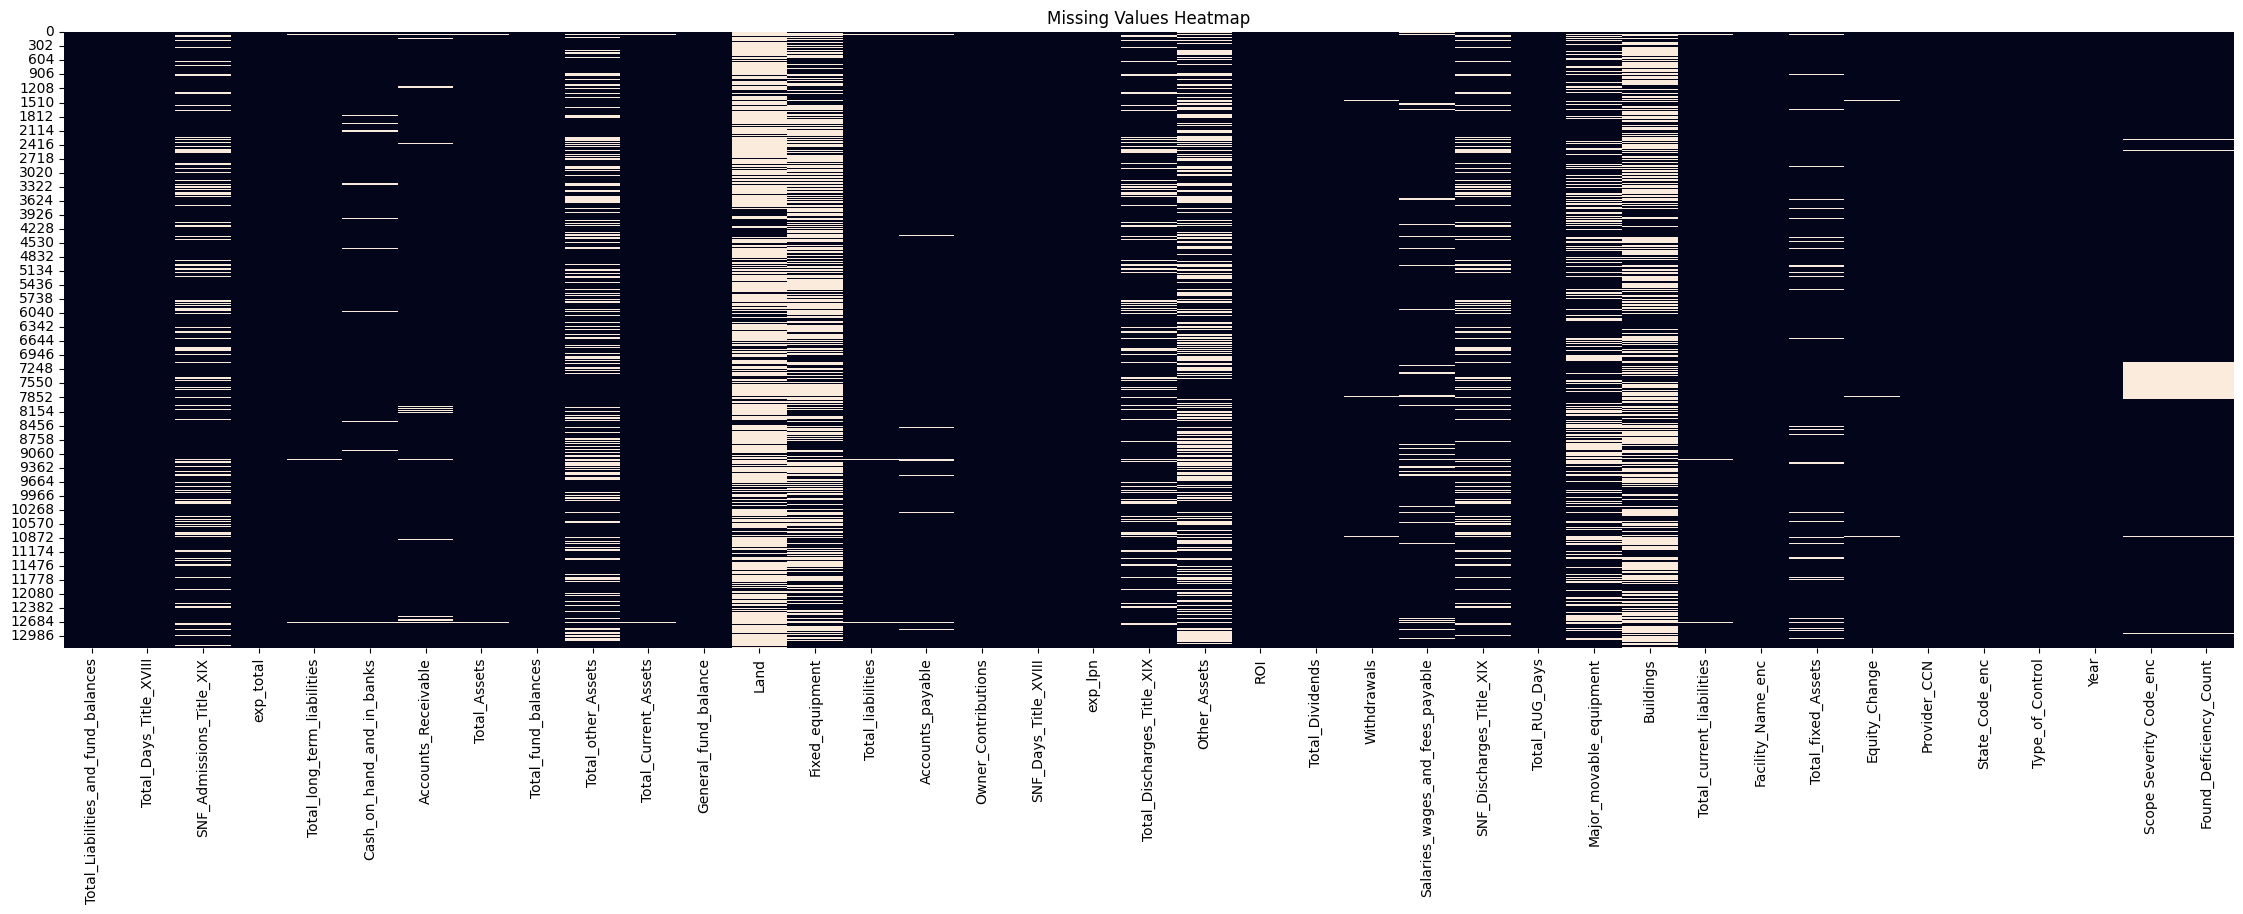

In [50]:
plt.figure(figsize=(28, 8))
sns.heatmap(combined_dataset.isnull(), cbar=False)   # and do df21
plt.title("Missing Values Heatmap")

In [51]:
# Calculate percentage of missing values
missing_percentage = (combined_dataset.isnull().sum() / len(combined_dataset)) * 100

# Convert to DataFrame for better readability
missing_df = pd.DataFrame(missing_percentage, columns=["Missing Percentage"])

# Sort in descending order and display the top 10 variables
top_missing = missing_df.sort_values(by="Missing Percentage", ascending=False).head(10)

# Display results
print(top_missing)


                            Missing Percentage
Land                                 74.480936
Fixed_equipment                      55.356738
Buildings                            54.624387
Other_Assets                         40.702152
Major_movable_equipment              29.301623
Total_other_Assets                   26.659117
SNF_Admissions_Title_XIX             14.949037
SNF_Discharges_Title_XIX             14.254436
Total_Discharges_Title_XIX           13.393733
Scope Severity Code_enc               7.240468


In [52]:
# I think i need to take out Other Assets and above
# other assets is 0.89 corr to Total Assets so np. 
# fixed equipment and building have a high corr with total long term liabilities so no problem.
# i need to take out land bc 75% missing it too much. 
# i did this while not having them dropped so i could see their corr below.


In [53]:
# Drop specified columns from the dataset
combined_dataset = combined_dataset.drop(columns=["Land", "Fixed_equipment", "Buildings", "Other_Assets"])

# Display the first few rows to confirm
combined_dataset.head()


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Total_long_term_liabilities,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_Assets,Total_fund_balances,Total_other_Assets,Total_Current_Assets,General_fund_balance,Total_liabilities,Accounts_payable,Owner_Contributions,SNF_Days_Title_XVIII,exp_lpn,Total_Discharges_Title_XIX,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,SNF_Discharges_Title_XIX,Total_RUG_Days,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Equity_Change,Provider_CCN,State_Code_enc,Type_of_Control,Year,Scope Severity Code_enc,Found_Deficiency_Count
0,1573239.0,2210.0,NaN,4.43882,0.0,139888.0,685258.0,1573239.0,1427672.0,NaN,825446.0,1427672.0,145567.0,145567.0,-78214.0,2210.0,0.70611,490.0,0.081255,5483.0,68785.0,NaN,490.0,2210.0,NaN,145567.0,1770,747793.0,64592.0,15009,1,4,2016,2.285714,0.0
1,780770.0,2772.0,49.0,3.99716,554018.0,106682.0,1274154.0,780770.0,-426152.0,-1122483.0,1088914.0,-426152.0,1206922.0,361606.0,77183.0,2772.0,0.61329,72.0,0.352665,665163.0,-77183.0,129851.0,72.0,2772.0,299288.0,652904.0,3352,814339.0,-154259.0,15014,1,4,2016,2.142857,10.0
2,272673.0,1311.0,NaN,3.73423,9.0,109551.0,978631.0,272673.0,-352982.0,-815703.0,862817.0,-352982.0,625655.0,373345.0,21627.0,1311.0,0.59307,NaN,-0.473256,-149740.0,-21627.0,139098.0,NaN,1311.0,420655.0,625646.0,9053,225559.0,-242788.0,15015,1,4,2016,2.210526,0.0
3,266720.0,3119.0,17.0,3.95112,NaN,NaN,NaN,NaN,266720.0,NaN,NaN,266720.0,NaN,NaN,340491.0,3119.0,0.62257,41.0,3.173890,1675302.0,360920.0,NaN,41.0,3119.0,NaN,NaN,739,NaN,-434691.0,15016,1,4,2016,2.210526,16.0
4,6052002.0,2588.0,61.0,3.72914,5994214.0,5937.0,839466.0,6052002.0,-470846.0,-929533.0,735534.0,-470846.0,6522848.0,293503.0,776878.0,2588.0,0.56677,104.0,-0.454333,-644777.0,-3054969.0,NaN,104.0,2588.0,196790.0,528634.0,7570,6246001.0,1807245.0,15019,1,4,2016,2.133333,11.0


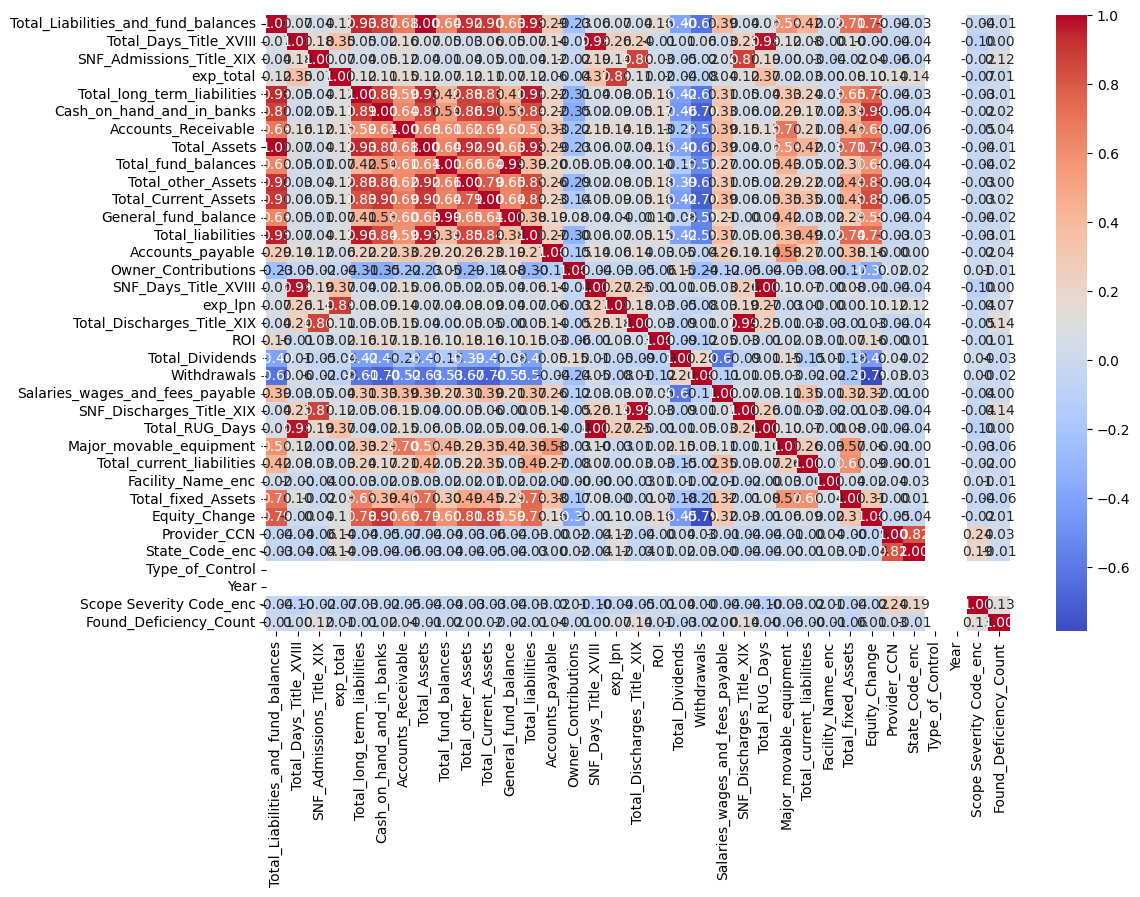

In [54]:
correlation_matrix = combined_dataset.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.show()

In [55]:
import pandas as pd
import numpy as np

# Compute correlation matrix
corr_matrix = combined_dataset.corr()

# Find pairs of variables with high correlation (above 0.7)
high_corr_pairs = np.where(np.abs(corr_matrix) > 0.7)

# Extract variable pairs and their correlation values
high_corr_list = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
                  for i, j in zip(*high_corr_pairs) if i != j and i < j]

# Display the correlated pairs
for var1, var2, corr_value in high_corr_list:
    print(f"{var1} and {var2}: {corr_value:.2f}")




Total_Liabilities_and_fund_balances and Total_long_term_liabilities: 0.93
Total_Liabilities_and_fund_balances and Cash_on_hand_and_in_banks: 0.87
Total_Liabilities_and_fund_balances and Total_Assets: 1.00
Total_Liabilities_and_fund_balances and Total_other_Assets: 0.92
Total_Liabilities_and_fund_balances and Total_Current_Assets: 0.90
Total_Liabilities_and_fund_balances and Total_liabilities: 0.95
Total_Liabilities_and_fund_balances and Total_fixed_Assets: 0.71
Total_Liabilities_and_fund_balances and Equity_Change: 0.79
Total_Days_Title_XVIII and SNF_Days_Title_XVIII: 0.98
Total_Days_Title_XVIII and Total_RUG_Days: 0.98
SNF_Admissions_Title_XIX and Total_Discharges_Title_XIX: 0.86
SNF_Admissions_Title_XIX and SNF_Discharges_Title_XIX: 0.87
exp_total and exp_lpn: 0.88
Total_long_term_liabilities and Cash_on_hand_and_in_banks: 0.89
Total_long_term_liabilities and Total_Assets: 0.93
Total_long_term_liabilities and Total_other_Assets: 0.88
Total_long_term_liabilities and Total_Current_Asse

In [56]:
# DROP
# Total_liabilities Total_RUG_Days SNF_Days_Title_XVIII SNF_Discharges_Title_XIX Total_Assets Total_other_Assets General_fund_balance Equity_Change Total_Current_Assets

In [57]:
# Drop specified columns from the dataset
combined_dataset = combined_dataset.drop(columns=[
    "Total_liabilities", "Total_RUG_Days", "SNF_Days_Title_XVIII", 
    "SNF_Discharges_Title_XIX", "Total_Assets", "Total_other_Assets", 
    "General_fund_balance", "Equity_Change", "Total_Current_Assets", "Total_long_term_liabilities"
])

# Display the first few rows to confirm
combined_dataset.head()


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_fund_balances,Accounts_payable,Owner_Contributions,exp_lpn,Total_Discharges_Title_XIX,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Provider_CCN,State_Code_enc,Type_of_Control,Year,Scope Severity Code_enc,Found_Deficiency_Count
0,1573239.0,2210.0,NaN,4.43882,139888.0,685258.0,1427672.0,145567.0,-78214.0,0.70611,490.0,0.081255,5483.0,68785.0,NaN,NaN,145567.0,1770,747793.0,15009,1,4,2016,2.285714,0.0
1,780770.0,2772.0,49.0,3.99716,106682.0,1274154.0,-426152.0,361606.0,77183.0,0.61329,72.0,0.352665,665163.0,-77183.0,129851.0,299288.0,652904.0,3352,814339.0,15014,1,4,2016,2.142857,10.0
2,272673.0,1311.0,NaN,3.73423,109551.0,978631.0,-352982.0,373345.0,21627.0,0.59307,NaN,-0.473256,-149740.0,-21627.0,139098.0,420655.0,625646.0,9053,225559.0,15015,1,4,2016,2.210526,0.0
3,266720.0,3119.0,17.0,3.95112,NaN,NaN,266720.0,NaN,340491.0,0.62257,41.0,3.173890,1675302.0,360920.0,NaN,NaN,NaN,739,NaN,15016,1,4,2016,2.210526,16.0
4,6052002.0,2588.0,61.0,3.72914,5937.0,839466.0,-470846.0,293503.0,776878.0,0.56677,104.0,-0.454333,-644777.0,-3054969.0,NaN,196790.0,528634.0,7570,6246001.0,15019,1,4,2016,2.133333,11.0


In [58]:
# Compute correlation of all variables with ROI
roi_correlation = combined_dataset.corr()["ROI"].sort_values(ascending=False)

# Convert to a DataFrame for better readability
roi_correlation_df = pd.DataFrame(roi_correlation).reset_index()
roi_correlation_df.columns = ["Variable", "Correlation with ROI"]

# Display the correlation values
print(roi_correlation_df)


                               Variable  Correlation with ROI
0                                   ROI              1.000000
1             Cash_on_hand_and_in_banks              0.172605
2   Total_Liabilities_and_fund_balances              0.156563
3                   Accounts_Receivable              0.125352
4                   Total_fund_balances              0.104924
5                    Total_fixed_Assets              0.074833
6       Salaries_wages_and_fees_payable              0.052647
7                      Accounts_payable              0.033949
8              SNF_Admissions_Title_XIX              0.033849
9             Total_current_liabilities              0.031351
10           Total_Discharges_Title_XIX              0.030708
11                              exp_lpn              0.027661
12              Major_movable_equipment              0.023688
13                            exp_total              0.023437
14               Found_Deficiency_Count              0.012650
15      

In [59]:
combined_dataset

,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_fund_balances,Accounts_payable,Owner_Contributions,exp_lpn,Total_Discharges_Title_XIX,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Provider_CCN,State_Code_enc,Type_of_Control,Year,Scope Severity Code_enc,Found_Deficiency_Count
0,1573239.0,2210.0,NaN,4.43882,139888.0,685258.0,1427672.0,145567.0,-78214.0,0.70611,490.0,0.081255,5483.0,68785.0,NaN,NaN,145567.0,1770,747793.0,15009,1,4,2016,2.285714,0.0
1,780770.0,2772.0,49.0,3.99716,106682.0,1274154.0,-426152.0,361606.0,77183.0,0.61329,72.0,0.352665,665163.0,-77183.0,129851.0,299288.0,652904.0,3352,814339.0,15014,1,4,2016,2.142857,10.0
2,272673.0,1311.0,NaN,3.73423,109551.0,978631.0,-352982.0,373345.0,21627.0,0.59307,NaN,-0.473256,-149740.0,-21627.0,139098.0,420655.0,625646.0,9053,225559.0,15015,1,4,2016,2.210526,0.0
3,266720.0,3119.0,17.0,3.95112,NaN,NaN,266720.0,NaN,340491.0,0.62257,41.0,3.173890,1675302.0,360920.0,NaN,NaN,NaN,739,NaN,15016,1,4,2016,2.210526,16.0
4,6052002.0,2588.0,61.0,3.72914,5937.0,839466.0,-470846.0,293503.0,776878.0,0.56677,104.0,-0.454333,-644777.0,-3054969.0,NaN,196790.0,528634.0,7570,6246001.0,15019,1,4,2016,2.133333,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13240,2881099.0,5353.0,45.0,NaN,1500.0,2895129.0,2338323.0,126263.0,-38409.0,NaN,22.0,-0.492046,-334885.0,NaN,175307.0,NaN,542776.0,13072,NaN,676402,44,4,2016,NaN,NaN
13241,59659.0,173.0,14.0,NaN,-36178.0,95837.0,-92885.0,29010.0,-509871.0,NaN,12.0,-1.828271,632298.0,NaN,NaN,NaN,152544.0,12489,NaN,676404,44,4,2016,NaN,NaN
13242,1029272.0,1307.0,9.0,NaN,18648.0,842641.0,474785.0,416732.0,390485.0,NaN,NaN,-8.187462,740931.0,NaN,27492.0,62030.0,554487.0,3857,116189.0,676405,44,4,2016,NaN,NaN
13243,7760304.0,2151.0,NaN,NaN,-7674.0,1164894.0,-1460343.0,446808.0,-3282686.0,NaN,NaN,-1.007482,2812119.0,NaN,51819.0,524261.0,8878010.0,8513,7089354.0,676407,44,4,2016,NaN,NaN


In [60]:
# Drop specified columns from the dataset
combined_dataset = combined_dataset.drop(columns=["Type_of_Control", "Year"])


In [61]:

# Display the first few rows to confirm
combined_dataset

,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_fund_balances,Accounts_payable,Owner_Contributions,exp_lpn,Total_Discharges_Title_XIX,ROI,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Provider_CCN,State_Code_enc,Scope Severity Code_enc,Found_Deficiency_Count
0,1573239.0,2210.0,NaN,4.43882,139888.0,685258.0,1427672.0,145567.0,-78214.0,0.70611,490.0,0.081255,5483.0,68785.0,NaN,NaN,145567.0,1770,747793.0,15009,1,2.285714,0.0
1,780770.0,2772.0,49.0,3.99716,106682.0,1274154.0,-426152.0,361606.0,77183.0,0.61329,72.0,0.352665,665163.0,-77183.0,129851.0,299288.0,652904.0,3352,814339.0,15014,1,2.142857,10.0
2,272673.0,1311.0,NaN,3.73423,109551.0,978631.0,-352982.0,373345.0,21627.0,0.59307,NaN,-0.473256,-149740.0,-21627.0,139098.0,420655.0,625646.0,9053,225559.0,15015,1,2.210526,0.0
3,266720.0,3119.0,17.0,3.95112,NaN,NaN,266720.0,NaN,340491.0,0.62257,41.0,3.173890,1675302.0,360920.0,NaN,NaN,NaN,739,NaN,15016,1,2.210526,16.0
4,6052002.0,2588.0,61.0,3.72914,5937.0,839466.0,-470846.0,293503.0,776878.0,0.56677,104.0,-0.454333,-644777.0,-3054969.0,NaN,196790.0,528634.0,7570,6246001.0,15019,1,2.133333,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13240,2881099.0,5353.0,45.0,NaN,1500.0,2895129.0,2338323.0,126263.0,-38409.0,NaN,22.0,-0.492046,-334885.0,NaN,175307.0,NaN,542776.0,13072,NaN,676402,44,NaN,NaN
13241,59659.0,173.0,14.0,NaN,-36178.0,95837.0,-92885.0,29010.0,-509871.0,NaN,12.0,-1.828271,632298.0,NaN,NaN,NaN,152544.0,12489,NaN,676404,44,NaN,NaN
13242,1029272.0,1307.0,9.0,NaN,18648.0,842641.0,474785.0,416732.0,390485.0,NaN,NaN,-8.187462,740931.0,NaN,27492.0,62030.0,554487.0,3857,116189.0,676405,44,NaN,NaN
13243,7760304.0,2151.0,NaN,NaN,-7674.0,1164894.0,-1460343.0,446808.0,-3282686.0,NaN,NaN,-1.007482,2812119.0,NaN,51819.0,524261.0,8878010.0,8513,7089354.0,676407,44,NaN,NaN


we have variables that are very complete, correlation of 1% to 17%, little multicollinearity, makes sense business wise to be there, no data leakage. 

In [62]:
dataset = combined_dataset

In [63]:
# Create a new column 'ROI_binary' where ROI is 1 if ROI > 0, else 0
dataset['ROI_binary'] = combined_dataset['ROI'].apply(lambda x: 1 if x > 0 else 0)



In [64]:
dataset = dataset.drop(columns=['ROI'])


In [65]:
# Fill missing values (NaNs) with the median of each column
dataset = dataset.apply(lambda x: x.fillna(x.median()), axis=0)

# Verify the change
print(dataset.isna().sum())

Total_Liabilities_and_fund_balances    0
Total_Days_Title_XVIII                 0
SNF_Admissions_Title_XIX               0
exp_total                              0
Cash_on_hand_and_in_banks              0
Accounts_Receivable                    0
Total_fund_balances                    0
Accounts_payable                       0
Owner_Contributions                    0
exp_lpn                                0
Total_Discharges_Title_XIX             0
Total_Dividends                        0
Withdrawals                            0
Salaries_wages_and_fees_payable        0
Major_movable_equipment                0
Total_current_liabilities              0
Facility_Name_enc                      0
Total_fixed_Assets                     0
Provider_CCN                           0
State_Code_enc                         0
Scope Severity Code_enc                0
Found_Deficiency_Count                 0
ROI_binary                             0
dtype: int64


In [66]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split dataset into features and target
X = dataset.drop(columns=["ROI_binary"])
y = dataset["ROI_binary"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.5595
Confusion Matrix:
 [[1432   36]
 [1131   50]]
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.98      0.71      1468
           1       0.58      0.04      0.08      1181

    accuracy                           0.56      2649
   macro avg       0.57      0.51      0.39      2649
weighted avg       0.57      0.56      0.43      2649



In [67]:
# Find the proportion of the majority class
benchmark_accuracy = dataset["ROI_binary"].value_counts(normalize=True).max()

print(f"Benchmark Accuracy: {benchmark_accuracy:.4f} ({benchmark_accuracy * 100:.2f}%)")


Benchmark Accuracy: 0.5541 (55.41%)


In [68]:
dataset["ROI_binary"].value_counts()


ROI_binary
0    7339
1    5906
Name: count, dtype: int64

In [69]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features and target variable
X = dataset.drop(columns=["ROI_binary"])  # Drop target column
y = dataset["ROI_binary"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize XGBoost classifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Define a smaller parameter grid for faster tuning
param_grid = {
    'n_estimators': [50, 100],          # Fewer trees
    'max_depth': [3, 5],                # Avoid deep trees for speed
    'learning_rate': [0.05, 0.1, 0.2],  # Small, medium, and large step sizes
    'subsample': [0.8, 1.0]             # Use most but not all data per tree
}

# Use RandomizedSearchCV for speed
random_search = RandomizedSearchCV(xgb_clf, param_grid, n_iter=10, scoring='accuracy', cv=3, n_jobs=-1, verbose=1, random_state=42)
random_search.fit(X_train, y_train)

# Get the best model from Randomized Search
best_xgb = random_search.best_estimator_

# Predict on test data
y_pred = best_xgb.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.2}
Accuracy: 0.6916

Confusion Matrix:
[[1110  358]
 [ 459  722]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      1468
           1       0.67      0.61      0.64      1181

    accuracy                           0.69      2649
   macro avg       0.69      0.68      0.68      2649
weighted avg       0.69      0.69      0.69      2649



In [70]:
# Create a mask for correctly predicted observations
correct_predictions = (y_pred == y_test)

# Create a dataset with all test observations
classified_dataset = X_test.copy()

# Add actual and predicted labels
classified_dataset["Actual"] = y_test.values
classified_dataset["Predicted"] = y_pred

# Add a column to indicate whether the classification was correct
classified_dataset["Correctly_Classified"] = correct_predictions.astype(int)

# Display the first few rows
classified_dataset.head()


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_fund_balances,Accounts_payable,Owner_Contributions,exp_lpn,Total_Discharges_Title_XIX,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Provider_CCN,State_Code_enc,Scope Severity Code_enc,Found_Deficiency_Count,Actual,Predicted,Correctly_Classified
5125,2418164.0,11738.0,29.0,4.67595,1267978.0,1274578.0,1376704.0,578779.0,-3945123.0,0.73745,46.0,1005314.0,4469692.0,238586.0,468149.0,1041460.0,7620,685236.5,215236,20,2.400000,10.0,0,0,1
5572,13072009.0,2200.0,22.0,3.93313,3230608.0,1590376.0,10785063.0,369631.0,-352850.0,0.61575,34.0,330466.0,352849.0,194686.0,1508236.0,1200650.0,5830,6178217.0,235011,22,2.884615,7.0,0,0,1
3042,6069517.0,6119.0,95.0,4.48841,17978.0,4958571.0,-839860.0,2954700.0,-717333.0,0.69573,127.0,-473758.0,728197.0,291543.0,426159.0,6909377.0,7350,327965.0,145885,14,2.322581,22.0,0,1,0
3028,7056250.0,7003.0,100.0,3.70939,175891.0,5661509.0,2451793.0,1483641.0,-2094785.0,0.56617,100.0,-676532.0,3294784.0,118837.0,316384.0,4334732.0,3808,76400.0,145864,14,2.487805,12.0,0,0,1
9390,1475830.0,8273.0,77.0,3.81066,1000.0,1189135.0,1065976.0,354413.0,-966767.0,0.62442,139.0,483366.0,966767.0,43860.0,611826.0,409854.0,4672,849998.0,375358,36,3.222222,9.0,0,0,1


In [71]:
# Merge classified_dataset with combined_dataset and df_no_outliers_iqr based on Provider_CCN
merged_dataset = classified_dataset.merge(
    combined_dataset[['Provider_CCN', 'ROI']], on='Provider_CCN', how='left'
).merge(
    df_no_outliers_iqr[['Provider_CCN', 'State_Code']], on='Provider_CCN', how='left'
)

# Display the first few rows of the merged dataset
merged_dataset


,Total_Liabilities_and_fund_balances,Total_Days_Title_XVIII,SNF_Admissions_Title_XIX,exp_total,Cash_on_hand_and_in_banks,Accounts_Receivable,Total_fund_balances,Accounts_payable,Owner_Contributions,exp_lpn,Total_Discharges_Title_XIX,Total_Dividends,Withdrawals,Salaries_wages_and_fees_payable,Major_movable_equipment,Total_current_liabilities,Facility_Name_enc,Total_fixed_Assets,Provider_CCN,State_Code_enc,Scope Severity Code_enc,Found_Deficiency_Count,Actual,Predicted,Correctly_Classified,ROI,State_Code
0,2418164.0,11738.0,29.0,4.67595,1267978.0,1274578.0,1376704.0,578779.0,-3945123.0,0.73745,46.0,1005314.0,4469692.0,238586.0,468149.0,1041460.0,7620,685236.5,215236,20,2.400000,10.0,0,0,1,-1.411973,MD
1,13072009.0,2200.0,22.0,3.93313,3230608.0,1590376.0,10785063.0,369631.0,-352850.0,0.61575,34.0,330466.0,352849.0,194686.0,1508236.0,1200650.0,5830,6178217.0,235011,22,2.884615,7.0,0,0,1,-0.342523,MI
2,6069517.0,6119.0,95.0,4.48841,17978.0,4958571.0,-839860.0,2954700.0,-717333.0,0.69573,127.0,-473758.0,728197.0,291543.0,426159.0,6909377.0,7350,327965.0,145885,14,2.322581,22.0,0,1,0,-0.698056,IL
3,7056250.0,7003.0,100.0,3.70939,175891.0,5661509.0,2451793.0,1483641.0,-2094785.0,0.56617,100.0,-676532.0,3294784.0,118837.0,316384.0,4334732.0,3808,76400.0,145864,14,2.487805,12.0,0,0,1,-1.608318,IL
4,1475830.0,8273.0,77.0,3.81066,1000.0,1189135.0,1065976.0,354413.0,-966767.0,0.62442,139.0,483366.0,966767.0,43860.0,611826.0,409854.0,4672,849998.0,375358,36,3.222222,9.0,0,0,1,-1.194920,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,951890.0,3347.0,20.0,3.81093,16809.0,847931.0,-671926.0,991812.0,172472.0,0.57899,39.0,-280556.0,-172473.0,185277.0,468149.0,1223043.0,13248,86491.0,245320,23,2.034483,0.0,0,0,1,-23.096930,MN
2974,1728158.0,5262.0,81.0,4.37338,45714.0,1076521.0,1261510.0,191950.0,-242683.0,0.70303,93.0,15676.0,242683.0,280451.0,468149.0,466648.0,4809,169609.0,345366,27,2.400000,2.0,0,0,1,-1.123148,NC
2975,1049664.0,7823.0,41.0,3.78865,192170.0,571680.0,427138.0,404661.0,-593774.0,0.57764,39.0,-82950.0,1280389.0,79491.0,468149.0,622526.0,5342,285406.0,45308,2,2.615385,2.0,0,0,1,-1.160103,AR
2976,5460169.0,2086.0,45.0,3.68132,78804.0,750868.0,3603633.0,223059.0,-386618.0,0.58565,44.0,928509.0,-186646.0,247716.0,468149.0,545114.0,4884,4323484.0,285112,29,2.555556,13.0,1,0,0,7.221106,NE


In [83]:
merged_dataset["ROI"].describe()

count    2978.000000
mean       -0.066457
std         8.492336
min       -83.949321
25%        -1.088866
50%        -0.166411
75%         0.696530
max        78.480646
Name: ROI, dtype: float64

In [84]:
import pandas as pd

# Define custom bin edges for ROI
bin_edges = [-85,-5, -1, -0.15, 0.7, 5, 80]  # Define appropriate bin edges for ROI
bin_labels = ['-85 to -5', '-5 to -1', '-1 to -0.15', '-0.15 to 0.7', '0.7 to 5', '5 to 80']  # Custom labels for intervals

# Bin ROI into the defined intervals with labels
merged_dataset['ROI_binned'] = pd.cut(merged_dataset['ROI'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# Check the result
print(merged_dataset[['ROI', 'ROI_binned']].head())


        ROI   ROI_binned
0 -1.411973     -5 to -1
1 -0.342523  -1 to -0.15
2 -0.698056  -1 to -0.15
3 -1.608318     -5 to -1
4 -1.194920     -5 to -1


In [89]:
import pandas as pd

# Define custom bin edges for ROI
bin_edges = [-85, -1, -0.15, 0.7, 80]  # Define appropriate bin edges for ROI
bin_labels = ['-85 to -1', '-1 to -0.15', '-0.15 to 0.7', '0.7 to 80']  # Custom labels for intervals

# Bin ROI into the defined intervals with labels
merged_dataset['ROI_binned'] = pd.cut(merged_dataset['ROI'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# Check the result
print(merged_dataset[['ROI', 'ROI_binned']].head())

        ROI   ROI_binned
0 -1.411973    -85 to -1
1 -0.342523  -1 to -0.15
2 -0.698056  -1 to -0.15
3 -1.608318    -85 to -1
4 -1.194920    -85 to -1


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float

ValueError: num must be an integer with 1 <= num <= 12, not 13

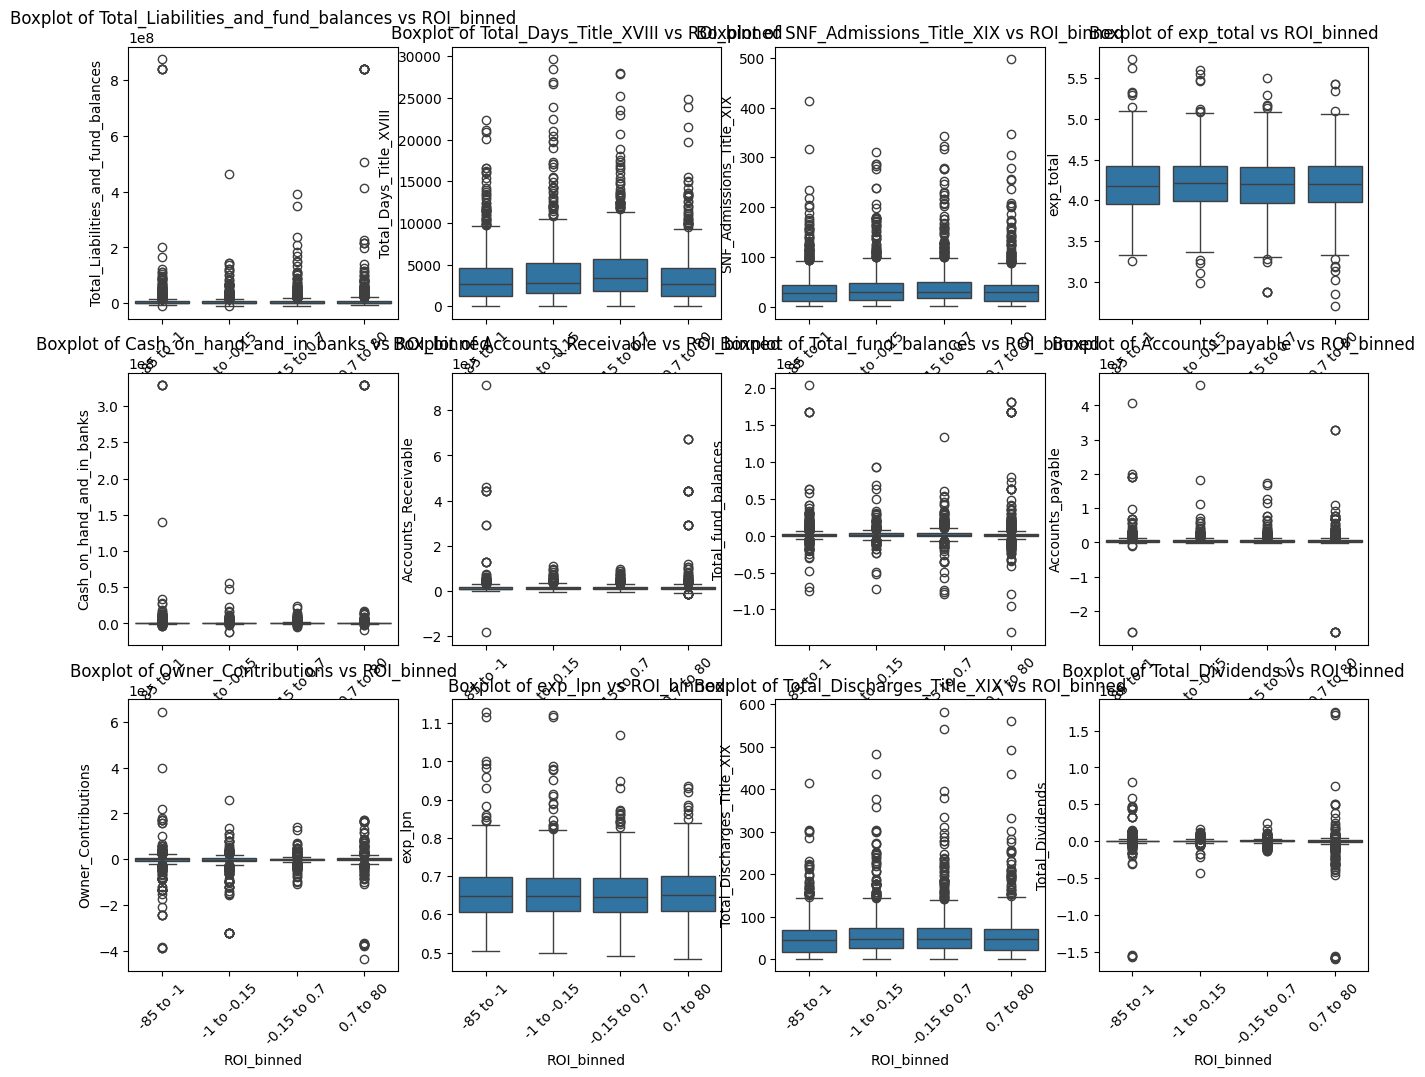

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Exclude the specified variables
excluded_vars = ['Actual', 'Predicted', 'Correctly_Classified', 'ROI', 'State_Code', 'Provider_CCN', 'State_Code_enc']
filtered_dataset = merged_dataset.drop(columns=excluded_vars)

# Step 3: Plot boxplots for each variable in the filtered dataset, grouped by ROI_binned
plt.figure(figsize=(16, 12))

# Iterate through each column in the filtered dataset
for i, column in enumerate(filtered_dataset.columns, 1):
    plt.subplot(3, 4, i)  # Create subplots for all the variables
    sns.boxplot(x=merged_dataset['ROI_binned'], y=filtered_dataset[column])
    plt.title(f'Boxplot of {column} vs ROI_binned')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [91]:
import scipy.stats as stats

# List of columns to exclude
exclude_columns = ['Actual', 'Predicted', 'Correctly_Classified', 'ROI', 'State_Code', 'Provider_CCN', 'State_Code_enc', 'ROI_binned']

# Remove the columns that need to be excluded
columns_to_analyze = [col for col in merged_dataset.columns if col not in exclude_columns]

# Initialize a dictionary to store p-values for each variable
p_values = {}

# Perform One-Way ANOVA for each variable
for column in columns_to_analyze:
    # Perform ANOVA: compare each group in 'ROI_binned' with the values in the column
    f_stat, p_val = stats.f_oneway(
        *[merged_dataset[merged_dataset['ROI_binned'] == label][column] for label in merged_dataset['ROI_binned'].cat.categories]
    )
    p_values[column] = p_val

# Display the p-values
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Variable', 'P-Value'])
p_values_df.sort_values(by='P-Value', ascending=True, inplace=True)

# Display variables with their p-values
print(p_values_df)

# Check which variables are statistically significant (p-value < 0.05)
significant_vars = p_values_df[p_values_df['P-Value'] < 0.05]
print("\nSignificant Variables (p-value < 0.05):")
print(significant_vars)


                               Variable       P-Value
1                Total_Days_Title_XVIII  2.057803e-07
12                          Withdrawals  1.206191e-05
5                   Accounts_Receivable  1.038663e-04
0   Total_Liabilities_and_fund_balances  1.105333e-03
17                   Total_fixed_Assets  1.489821e-03
19               Found_Deficiency_Count  1.981915e-03
4             Cash_on_hand_and_in_banks  3.762959e-03
10           Total_Discharges_Title_XIX  5.047762e-03
11                      Total_Dividends  6.034947e-03
8                   Owner_Contributions  1.874840e-02
2              SNF_Admissions_Title_XIX  2.279996e-02
6                   Total_fund_balances  5.287474e-02
14              Major_movable_equipment  7.103337e-02
16                    Facility_Name_enc  2.642589e-01
18              Scope Severity Code_enc  3.785363e-01
13      Salaries_wages_and_fees_payable  4.377947e-01
3                             exp_total  6.513044e-01
9                           

In [93]:
# Step 1: Identify the significant variables (p-value < 0.05)
significant_vars = p_values_df[p_values_df['P-Value'] < 0.05]['Variable'].tolist()

# Step 2: Filter merged_dataset for the bins '0.7 to 5' and '5 to 80'
bin_1 = merged_dataset[merged_dataset['ROI_binned'] == '0.7 to 80']
rest_of_data = merged_dataset[~merged_dataset['ROI_binned'].isin(['0.7 to 80'])]

# Step 3: Calculate the median for each significant variable in the two bins and the rest of the dataset
median_results = {}

for var in significant_vars:
    # Median in '0.7 to 5' bin
    median_bin_1 = bin_1[var].median() if var in bin_1.columns else None
   

    # Median in the rest of the data
    median_rest = rest_of_data[var].median() if var in rest_of_data.columns else None
    
    # Store the results
    median_results[var] = {
        'Median_0.7_to_80': median_bin_1,
        'Median_Rest': median_rest
    }

# Convert results to a DataFrame for better readability
median_results_df = pd.DataFrame.from_dict(median_results, orient='index')

# Display the median values for each significant variable
print(median_results_df)


                                     Median_0.7_to_80  Median_Rest
Total_Days_Title_XVIII                         2682.0       2996.0
Withdrawals                                  171980.0     169837.0
Accounts_Receivable                         1048932.0    1018548.0
Total_Liabilities_and_fund_balances         2912248.0    2764826.0
Total_fixed_Assets                           685236.5     685236.5
Found_Deficiency_Count                            3.0          3.0
Cash_on_hand_and_in_banks                     87833.0      87623.0
Total_Discharges_Title_XIX                       46.0         46.0
Total_Dividends                              131860.0     172861.0
Owner_Contributions                          -56450.0    -106434.0
SNF_Admissions_Title_XIX                         29.0         29.0


There is not a huge difference between the predicted correctly observations with significant varaibles whose ROI is >0.7 and <0.7 when looking at the difference variable by variable. 

# EXTRA ATTEMPTS THAT ARENT GOOD

Text(0.5, 1.0, 'Missing Values Heatmap')

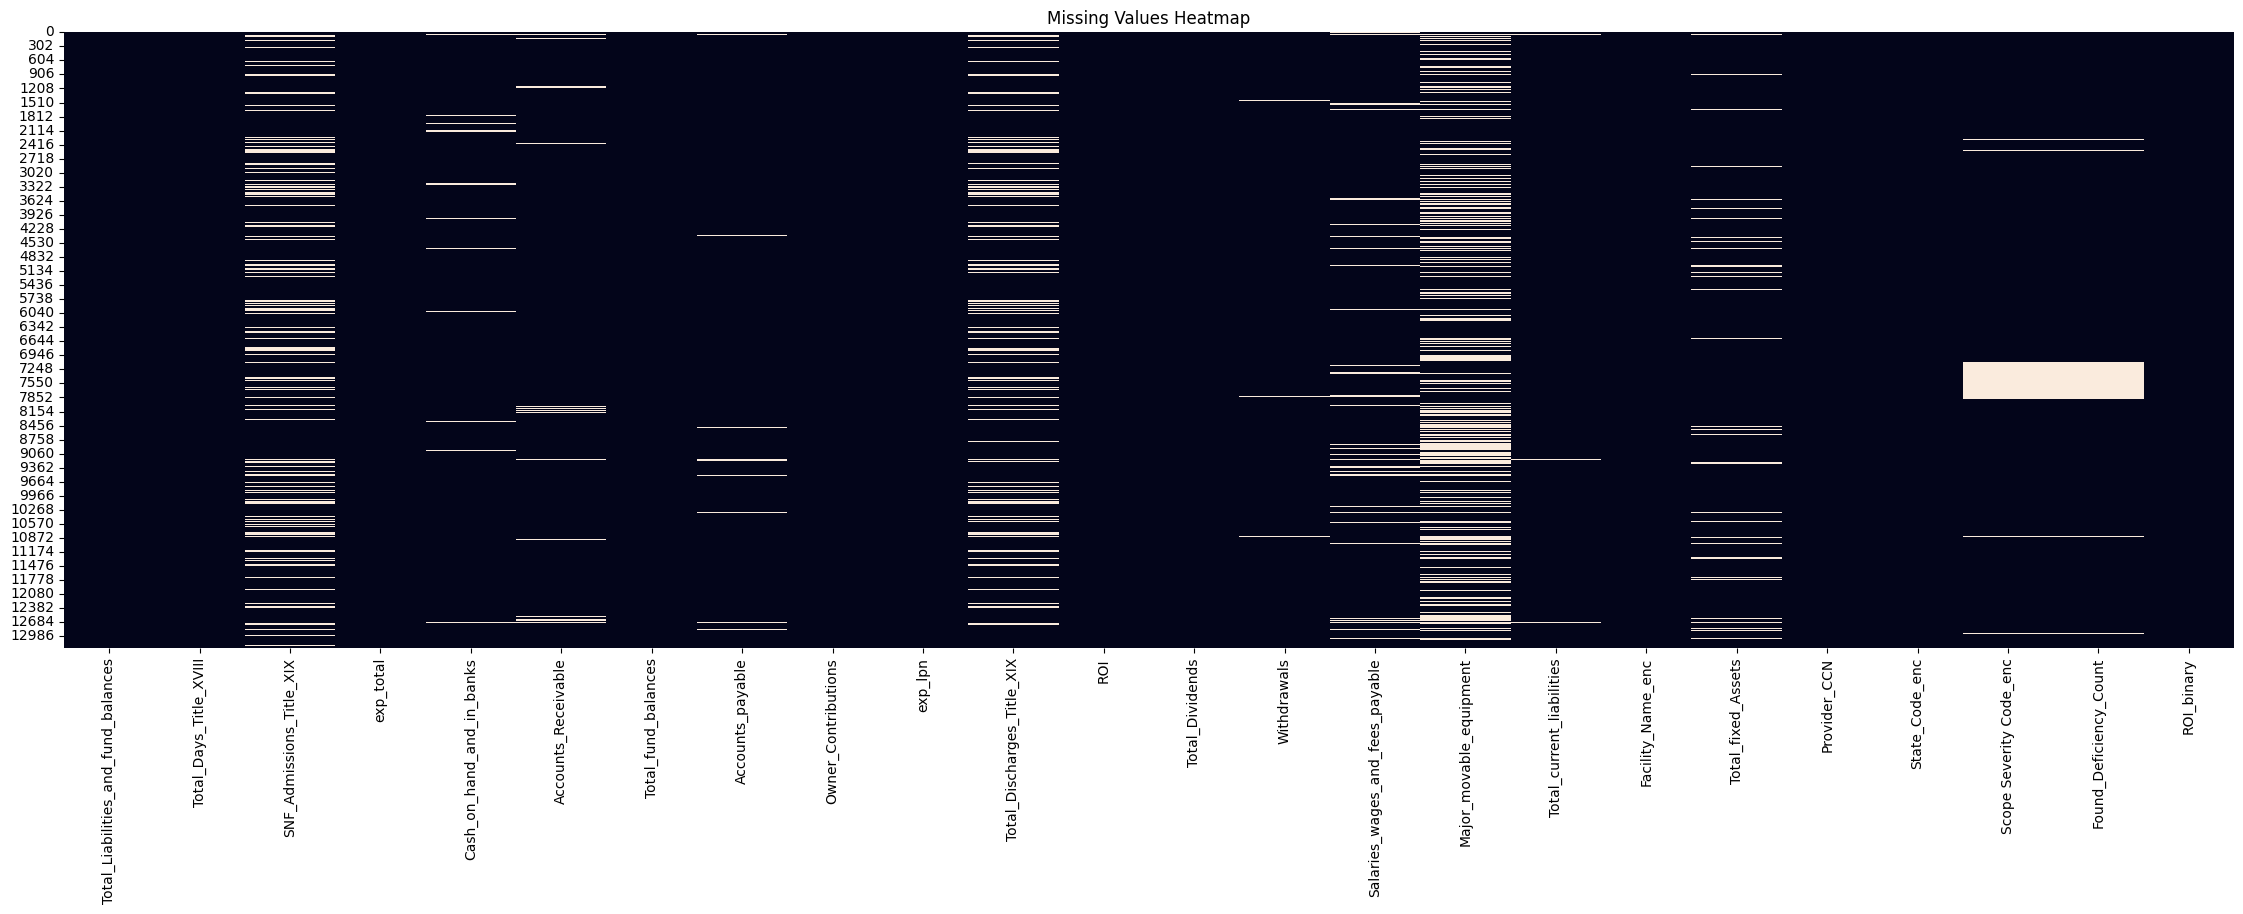

In [72]:
plt.figure(figsize=(28, 8))
sns.heatmap(combined_dataset.isnull(), cbar=False)   # and do df21
plt.title("Missing Values Heatmap")

In [73]:
# Fill missing values (NaNs) with the median of each column
combined_dataset = combined_dataset.apply(lambda x: x.fillna(x.median()), axis=0)

# Verify the change
print(combined_dataset.isna().sum())


Total_Liabilities_and_fund_balances    0
Total_Days_Title_XVIII                 0
SNF_Admissions_Title_XIX               0
exp_total                              0
Cash_on_hand_and_in_banks              0
Accounts_Receivable                    0
Total_fund_balances                    0
Accounts_payable                       0
Owner_Contributions                    0
exp_lpn                                0
Total_Discharges_Title_XIX             0
ROI                                    0
Total_Dividends                        0
Withdrawals                            0
Salaries_wages_and_fees_payable        0
Major_movable_equipment                0
Total_current_liabilities              0
Facility_Name_enc                      0
Total_fixed_Assets                     0
Provider_CCN                           0
State_Code_enc                         0
Scope Severity Code_enc                0
Found_Deficiency_Count                 0
ROI_binary                             0
dtype: int64


BENCH MARK

In [74]:
# Importing necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assume your dataset is already loaded in combined_dataset
# We will split the data into features (X) and target (y)
X = combined_dataset.drop('ROI', axis=1)  # Drop 'ROI' for features
y = combined_dataset['ROI']  # Target variable is 'ROI'

# Step 1: Scale the data (if needed)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Step 5: Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Step 6: Display the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")


Mean Absolute Error (MAE): 3.3962846290155433
Mean Squared Error (MSE): 54.329719341726616
Root Mean Squared Error (RMSE): 7.370869646230804
R-squared: 0.16150304370766133


# SPLITTING 

In [75]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming 'X' is the features (independent variables) and 'y' is the target (ROI)
X = combined_dataset.drop(columns=['ROI'])  # Drop the target column
y = combined_dataset['ROI']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

I dont need to scale for decision tree or random forest

In [76]:


# Define the model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Get the best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")


Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best parameters found: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mean Absolute Error (MAE): 3.1233394995017525
Mean Squared Error (MSE): 48.98482859901456
Root Mean Squared Error (RMSE): 6.9989162446063435
R-squared: 0.2439933395122471


In [77]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [78]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X is your features


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [80]:
# Initialize MLPRegressor
mlp_regressor = MLPRegressor(hidden_layer_sizes=(100,), max_iter=100, random_state=42)

# Train the model
mlp_regressor.fit(X_train, y_train)


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=100, random_state=42)

In [81]:
# Predict on the test set
y_pred = mlp_regressor.predict(X_test)

# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")


Mean Absolute Error (MAE): 3.3811497625271785
Mean Squared Error (MSE): 51.59191517983743
Root Mean Squared Error (RMSE): 7.18275122636427
R-squared: 0.20375690558074255


In [82]:

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model
mlp_regressor = MLPRegressor(random_state=42, max_iter=10)

# Define the parameter grid for GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (200,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=mlp_regressor, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Get the best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test_scaled)

# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared: {r2}")


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters found: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (200,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'solver': 'adam'}
Mean Absolute Error (MAE): 3.3532317711677337
Mean Squared Error (MSE): 53.94875088492976
Root Mean Squared Error (RMSE): 7.3449813399987445
R-squared: 0.16738271500613267


C:\Users\lukep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
